In [1]:
#General
import re
import sys
import pprint
import seaborn as sb
import numpy   as np
import pandas  as pd
import random  as rnd

from bios    import read
from os.path import isfile
from copy    import deepcopy
from time    import time
from tqdm    import tqdm
from getdist import plots
import yaml

from scipy.interpolate import interp1d
from scipy.stats       import multivariate_normal
from itertools         import repeat

from getdist import plots,loadMCSamples,MCSamples
from getdist.gaussian_mixtures import GaussianND
sys.path.insert(0, '/Users/chiaradeleo/Desktop/6x2pt/')
from analysis.chains_analysis import Analyzer

#Plotting
import matplotlib
import matplotlib.pyplot as plt

from matplotlib import rc

rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}
bottomlegend = {'bbox_to_anchor': (0.35,-0.2), 
                'loc': "center left",
                'frameon': False,
                'ncols': 3}

use_estimator = 'Best-Fit'

analysis_settings = {'Metropolis-Hastings': {'ignore_rows': 0.3},
                     'Nautilus': {}}

In [2]:
chains_LCDM = {
             r'$\Lambda$CDM 3 $\times$ 2 pt ': {'path': '/Users/chiaradeleo/Desktop/6x2pt/chains_final_noiseless/LCDM_3x2pt_final_sigma8',         
                                                'sampler': 'Nautilus',
                                                'color': 'plum',#gal_palette[len(gal_palette)//2],
                                                'linestyle': '-',
                                                'alpha': 0.7,
                                                'filled': True},
            r'$\Lambda$CDM 10 $\times$ 2 pt ': {'path': '/Users/chiaradeleo/Desktop/6x2pt/chains_final_noiseless/LCDM_3x2pt+GW_final_sigma8',     
                                                'sampler': 'Nautilus',
                                                'color': '#5C0120', #gw_palette[len(gw_palette)//2],
                                                'linestyle': '--',
                                                'alpha':1.0,
                                                'filled': False},

          }
cosmo_pars = [ 'H0',  'omch2',  'sigma8']

nuis_pars_IA = ['a0', 'a1', 'a2', 'a3', 'a4']
nuis_pars_bias = ['b0_poly','b1_poly','b2_poly','b3_poly', 'b0_poly_GW','b1_poly_GW','b2_poly_GW','b3_poly_GW']

In [3]:
chains_muSigma = {

            r'$\mu\Sigma$CDM 3 $\times$ 2 pt': {'path': '/Users/chiaradeleo/Desktop/6x2pt/chains_final_noiseless/muSigmaCDM_3x2pt_final_sigma8',      
                                                'sampler': 'Nautilus',
                                                'color': 'yellowgreen',#gal_palette[len(gal_palette)-2],
                                                'filled': True,
                                                'alpha': 0.7,
                                                'linestyle': '-'},
            r'$\mu\Sigma$CDM  10 $\times$ 2 pt': {'path': '/Users/chiaradeleo/Desktop/6x2pt/chains_final_noiseless/muSigmaCDM_3x2pt+GW_final_sigma8',     
                                                'sampler': 'Nautilus',
                                                'color': 'darkolivegreen',#gw_palette[len(gw_palette)//2],
                                                'linestyle': '--',
                                                'alpha':1.0,
                                                'filled': False},
}

In [4]:
fiducial = {'ombh2': 0.0227,
            'omch2': 0.1205579307,
            'ns': 0.96,
            'As': 2.12605e-09,
            'H0': 67.,
            'w': -1.,
            'wa': 0.,
            'tau': 0.05,
            'mnu': 0.06,
            'a0': - 0.007589,
            'a1' :  0.002008,
            'a2' : - 0.004127,
            'a3' :  0.002918,
            'a4' : -0.0006784,
            'omegab': 0.05,
            'sigma8': 0.84,
            'omegam' : 0.31,
            #'A_IA': 1.72,
            #'eta_IA': -0.41,
            'b0_poly': 0.830703,
            'b1_poly': 1.190547,
            'b2_poly': -0.928357,
            'b3_poly': 0.423292,
            'sigma0': 0.0,
            'mu0': 0.0,
            'sigma8':0.8136896308055027,
           }
fiducial['logA'] = np.log(fiducial['As']*1.e+10)
print(fiducial['logA'])

3.0568508909815586


In [5]:
stats = Analyzer(analysis_settings,fiducial)

In [6]:
results_LCDM = {name: stats.analyze_chain(name,chain) for name,chain in chains_LCDM.items()} 

Nautilus
dict_keys(['path', 'sampler', 'color', 'linestyle', 'alpha', 'filled', 'outyaml', 'Nautilus pars', 'Raw chains'])

 Analyzing $\Lambda$CDM 3 $\times$ 2 pt  
Removed no burn in
\begin{tabular} { l  c}

 Parameter &  68\% limits\\
\hline
{\boldmath$\Omega_\mathrm{b} h^2$} & $0.0227\pm 0.0017          $\\

{\boldmath$\Omega_\mathrm{c} h^2$} & $0.1212\pm 0.0046          $\\

{\boldmath$n_\mathrm{s}   $} & $0.9592\pm 0.0080          $\\

{\boldmath$H_0            $} & $67.2\pm 1.5               $\\

{\boldmath$\log(10^{10} A_\mathrm{s})$} & $3.054\pm 0.028            $\\

{\boldmath$a_0            $} & $-0.007588\pm 0.000026     $\\

{\boldmath$a_1            $} & $0.002008\pm 0.000036      $\\

{\boldmath$a_2            $} & $-0.004128\pm 0.000057     $\\

{\boldmath$a_3            $} & $0.002918\pm 0.000037      $\\

{\boldmath$a_4            $} & $-0.000678\pm 0.000011     $\\

{\boldmath$b_0            $} & $0.8308\pm 0.0033          $\\

{\boldmath$b_1            $} & $1.1902\

In [7]:
results_muSigma = {name: stats.analyze_chain(name,chain) for name,chain in chains_muSigma.items()} 

Nautilus
dict_keys(['path', 'sampler', 'color', 'filled', 'alpha', 'linestyle', 'outyaml', 'Nautilus pars', 'Raw chains'])

 Analyzing $\mu\Sigma$CDM 3 $\times$ 2 pt 
Removed no burn in
\begin{tabular} { l  c}

 Parameter &  68\% limits\\
\hline
{\boldmath$\Omega_\mathrm{b} h^2$} & $0.0227\pm 0.0017          $\\

{\boldmath$\Omega_\mathrm{c} h^2$} & $0.1215\pm 0.0050          $\\

{\boldmath$n_\mathrm{s}   $} & $0.9588\pm 0.0089          $\\

{\boldmath$H_0            $} & $67.3\pm 1.8               $\\

{\boldmath$\log(10^{10} A_\mathrm{s})$} & $3.051\pm 0.034            $\\

{\boldmath$a_0            $} & $-0.007588\pm 0.000035     $\\

{\boldmath$a_1            $} & $0.002008\pm 0.000036      $\\

{\boldmath$a_2            $} & $-0.004126\pm 0.000057     $\\

{\boldmath$a_3            $} & $0.002917\pm 0.000037      $\\

{\boldmath$a_4            $} & $-0.000678\pm 0.000011     $\\

{\boldmath$b_0            $} & $0.8305\pm 0.0068          $\\

{\boldmath$b_1            $} & $1.1907

In [8]:

font_legend = 25
font_axes   = 23

## $\Lambda CDM$ cosmological params LSS vs. LSS $\times$ GWs

/var/folders/n0/q76k2fl902l89_80wvtgb81r0000gn/T/ipykernel_54094/3107672633.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


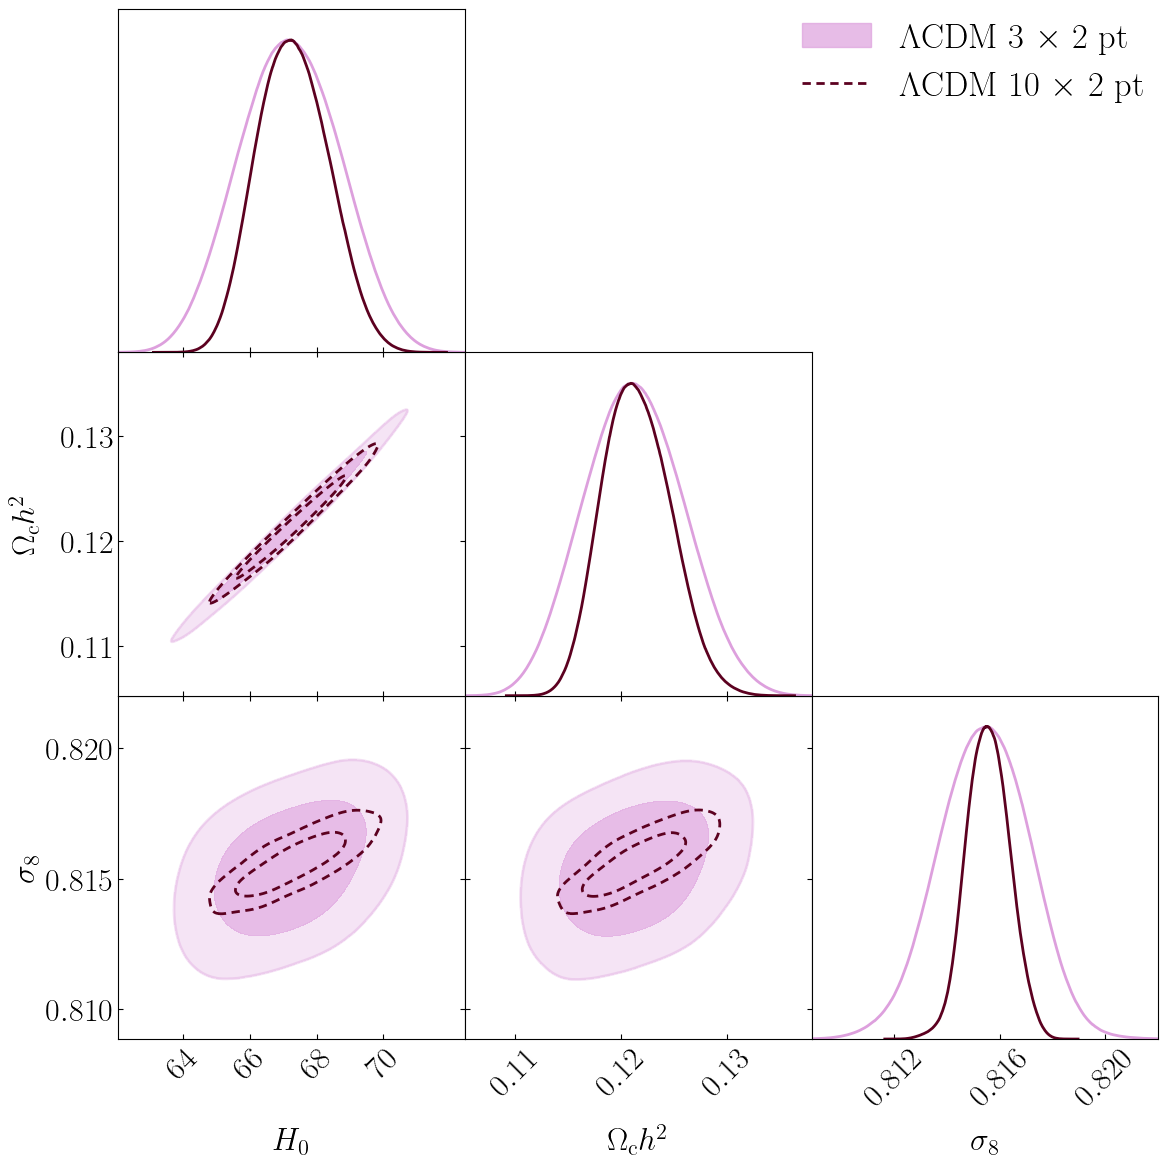

In [9]:
g = plots.get_subplot_plotter(subplot_size=1,width_inch=12, scaling=False)
g.settings.figure_legend_frame = False
g.settings.axes_fontsize=font_axes
g.settings.axes_labelsize=font_axes
g.settings.legend_fontsize=font_legend
g.settings.axis_marker_color = 'black'
g.settings.axis_marker_ls = '--'
g.settings.axis_marker_lw = 1
g.settings.axis_tick_x_rotation = 45
g.triangle_plot([result['MCsamples'] for result in results_LCDM.values()], cosmo_pars,
    filled=[result['filled'] for result in results_LCDM.values()],
    legend_loc='upper right',
    legend_labels=[result for result in results_LCDM.keys()],
    contour_colors=[result['color'] for result in results_LCDM.values()],
    contour_lws=2,
    alphas=[result['alpha'] for result in results_LCDM.values()],
    ls=[result['linestyle'] for result in results_LCDM.values()],
    #markers={k:v for k,v in fiducial.items()}
    )    
g.fig.align_ylabels()
g.fig.align_xlabels()
plt.tight_layout()
plt.savefig("./Results/LCDM_cosmo.pdf", dpi=300, bbox_inches='tight')

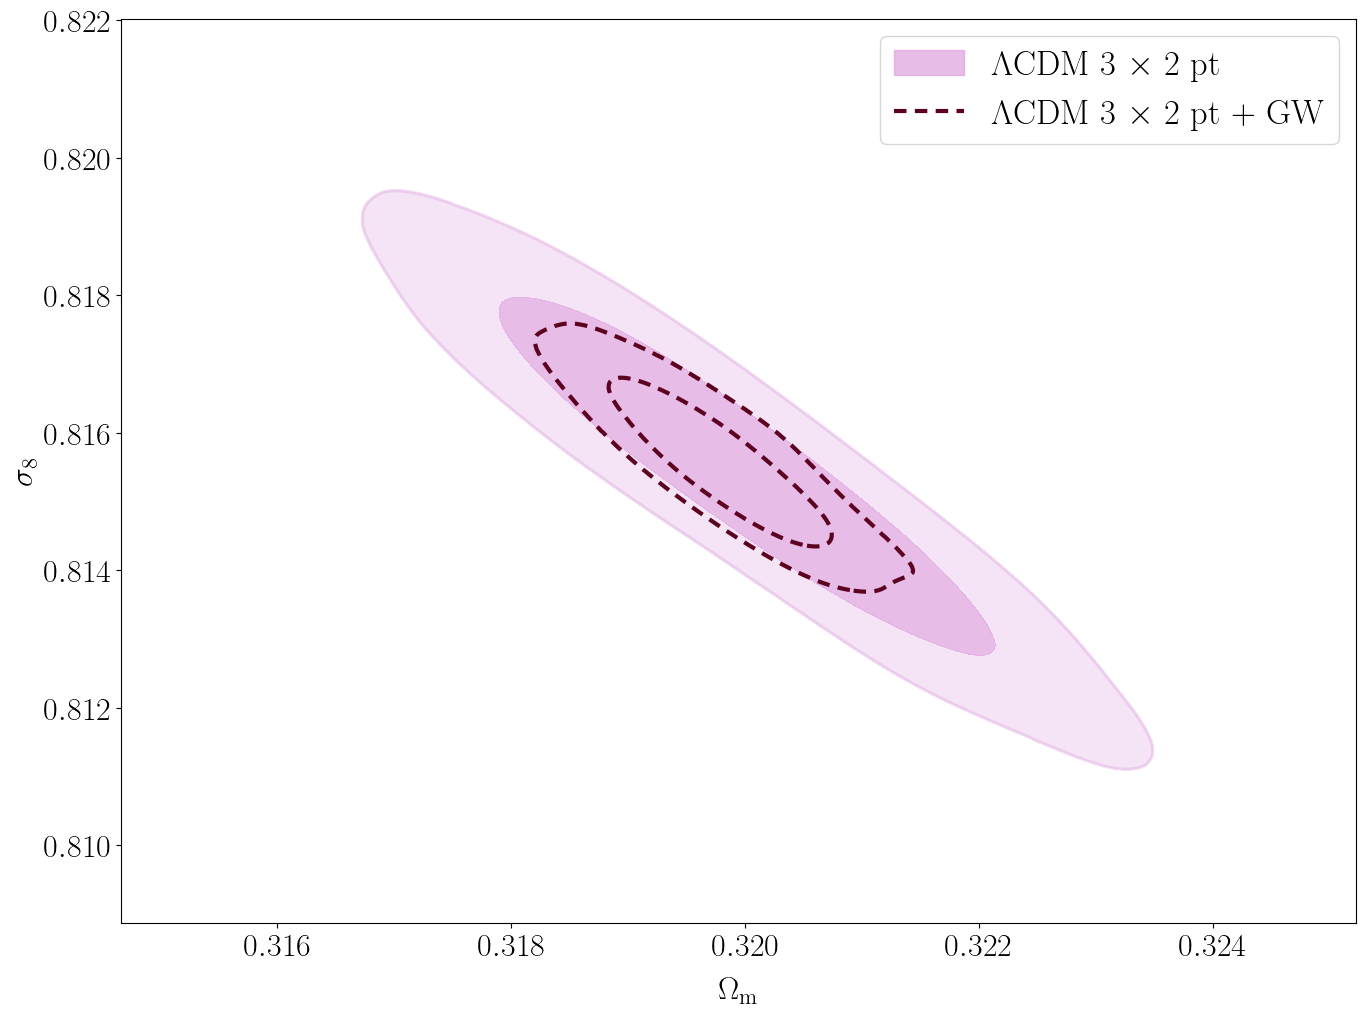

In [10]:
from getdist import plots

g = plots.get_single_plotter(width_inch=14)
g.settings.figure_legend_frame = False
g.settings.legend_fontsize     = font_legend
g.settings.axes_fontsize       = font_axes
g.settings.axes_labelsize      = font_axes
g.settings.num_plot_contours = 2


g.plot_2d(
    [res['MCsamples'] for res in results_LCDM.values()],
    ['omegam', 'sigma8'],
    filled=[res['filled'] for res in results_LCDM.values()],
    colors=[res['color'] for res in results_LCDM.values()],
    lws=[0,3],
    alphas=[res['alpha'] for res in results_LCDM.values()],
    ls=[res['linestyle'] for res in results_LCDM.values()],
)

g.add_legend(
    legend_labels=list(results_LCDM.keys()),
    legend_loc='upper right'
)


/var/folders/n0/q76k2fl902l89_80wvtgb81r0000gn/T/ipykernel_54094/1084220531.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


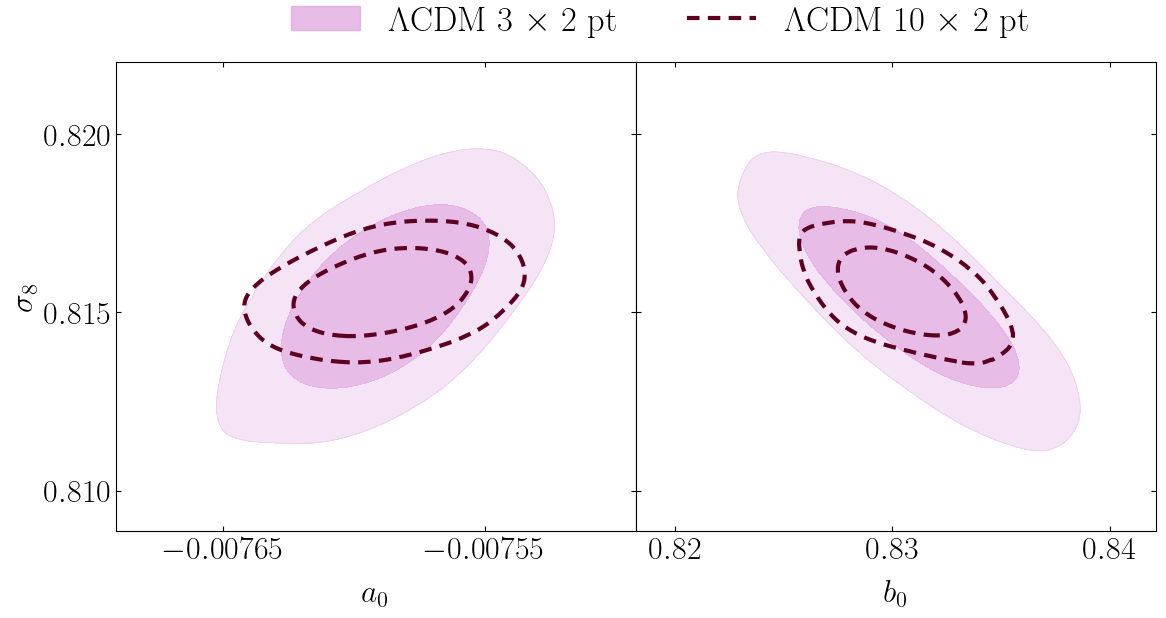

In [10]:
from getdist import plots

g = plots.get_subplot_plotter(subplot_size=1, width_inch=12, scaling=False)
g.settings.axes_fontsize =font_axes
g.settings.figure_legend_frame = False
g.settings.legend_fontsize = font_legend
g.settings.axes_labelsize = font_axes
g.rectangle_plot(
    ['a0', 'b0_poly'],
    'sigma8',
    roots=[result['MCsamples'] for result in results_LCDM.values()],
    colors=[result['color'] for result in results_LCDM.values()],
    filled=[result['filled'] for result in results_LCDM.values()],
    alphas=[result['alpha'] for result in results_LCDM.values()],
    ls=[result['linestyle'] for result in results_LCDM.values()],
    lws=[0,3]
)
leg = g.fig.legends[0]
leg.set_bbox_to_anchor((0.55, 0.945))   
plt.tight_layout()
plt.savefig("./Results/LCDM_sigma8_nuis.pdf", dpi=300, bbox_inches='tight')

In [11]:
cosmo_pars += ['mu0', 'sigma0']

In [13]:
import matplotlib.pyplot as plt

def plot_raw_chain(analyzed_results, par="omch2", sidelegend={"loc": "upper right"}):
    """
    analyzed_results : dict {name: analysis_result}
        The output of results_muSigma = {name: stats.analyze_chain(...)}

    par : str
        Parameter to plot (e.g. 'omch2')
    """

    fig, axes = plt.subplots(
        nrows=len(analyzed_results),
        sharex=False,
        figsize=(8, 3 * len(analyzed_results)),
        subplot_kw=dict(frameon=True)
    )

    if len(analyzed_results) == 1:
        axes = [axes]

    # Assign subplot titles
    for ax, name in zip(axes, analyzed_results.keys()):
        ax.set_title(name)

    # Loop over chains
    for ax, (name, chain) in zip(axes, analyzed_results.items()):

        raw_chains = chain["Raw chains"]

        chain_numbers = raw_chains["Chain number"].unique()

        for Nc in chain_numbers:
            raw = raw_chains[raw_chains["Chain number"] == Nc].reset_index(drop=True)

            if par in raw.columns:
                ax.plot(
                    raw.index,
                    raw[par].values,
                    label=f"Chain {Nc}",
                    alpha=0.7
                )

        # Plot mean & best-fit (Estimators)
        if par in chain["Estimators"].index:
            for ls, est in zip(["-", ":"], ["Mean", "Best-Fit"]):
                val = chain["Estimators"].loc[par][chain["Estimators"]["Type"] == est]
                if len(val) > 0:
                    ax.axhline(
                        y=val.values[0],
                        ls=ls,
                        color="black",
                        lw=2.5,
                        label=est,
                        zorder=10
                    )

        ax.set_xscale("log")
        ax.set_ylabel(par)

    plt.xlabel("Index")
    plt.subplots_adjust(hspace=0.4)
    plt.show()


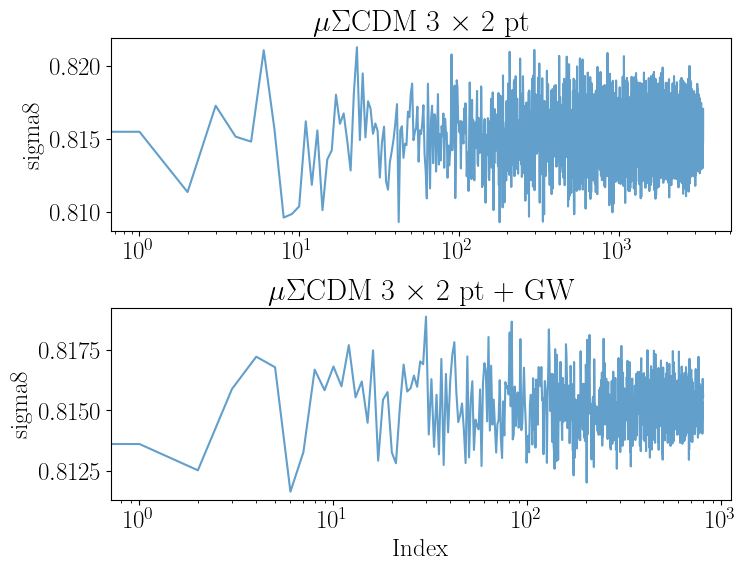

In [14]:
plot_raw_chain(results_muSigma, par="sigma8")



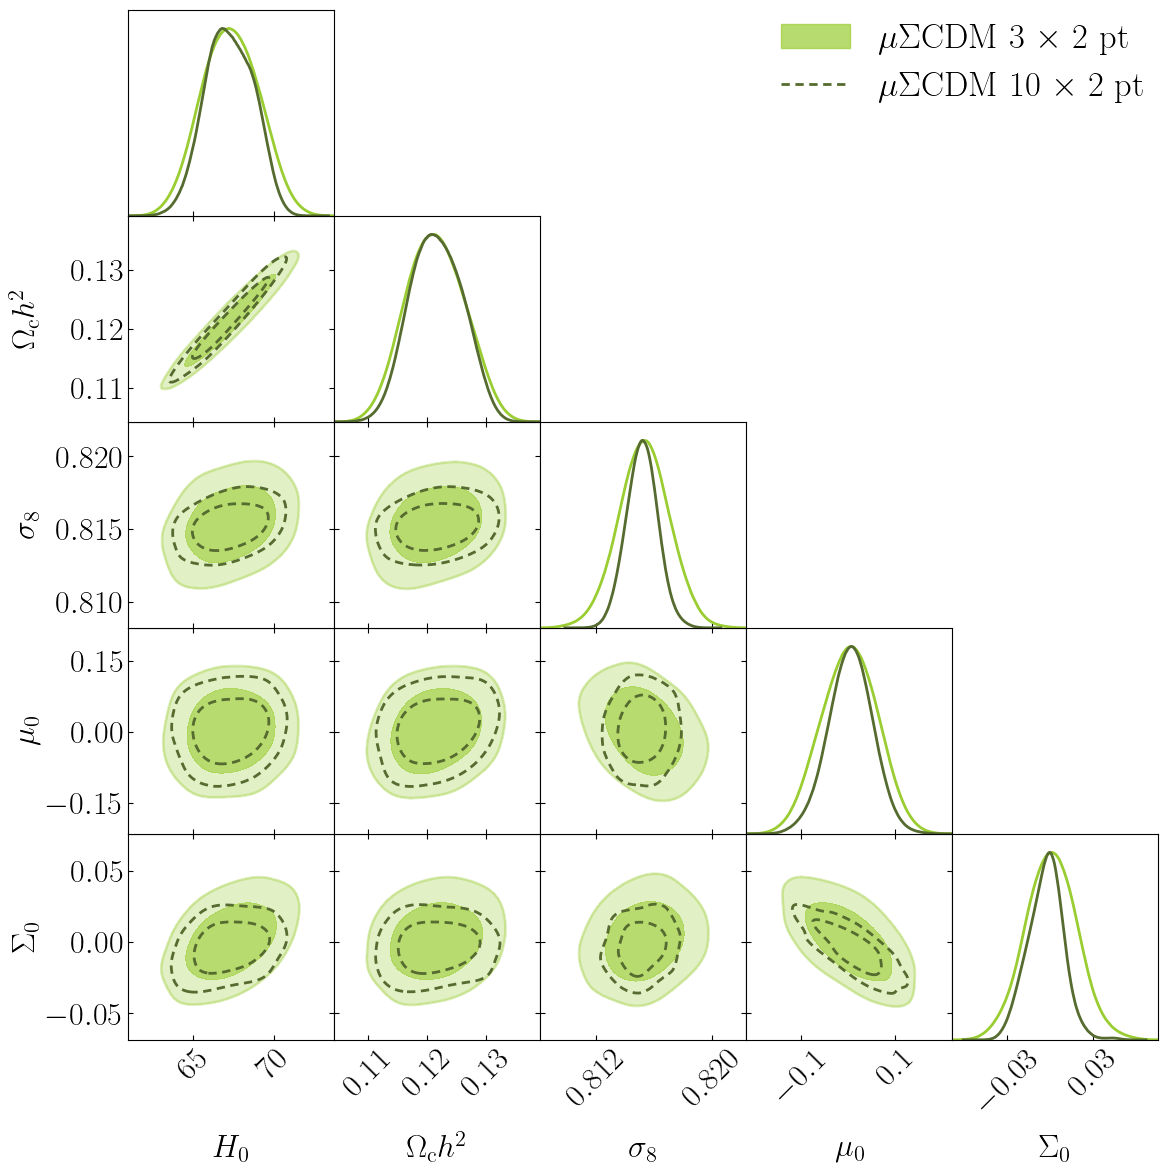

In [12]:
g = plots.get_subplot_plotter(subplot_size=1,width_inch=12, scaling=False)
g.settings.figure_legend_frame = False
g.settings.axes_fontsize=font_axes
g.settings.axes_labelsize=font_axes
g.settings.legend_fontsize=font_legend
g.settings.axis_marker_color = 'black'
g.settings.axis_marker_ls = '--'
g.settings.axis_marker_lw = 1
g.settings.axis_tick_x_rotation = 45
g.triangle_plot([result['MCsamples'] for result in results_muSigma.values()], cosmo_pars,
    filled=[result['filled'] for result in results_muSigma.values()],
    legend_loc='upper right',
    legend_labels=[result for result in results_muSigma.keys()],
    contour_colors=[result['color'] for result in results_muSigma.values()],
    contour_lws=2,
    alphas=[result['alpha'] for result in results_muSigma.values()],
    ls=[result['linestyle'] for result in results_muSigma.values()],
    #markers={k:v for k,v in fiducial.items()}
    )    
g.fig.align_ylabels()
g.fig.align_xlabels()
plt.savefig("./Results/muSigma_cosmo.pdf", dpi=300, bbox_inches='tight')

/var/folders/n0/q76k2fl902l89_80wvtgb81r0000gn/T/ipykernel_51068/2678433162.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


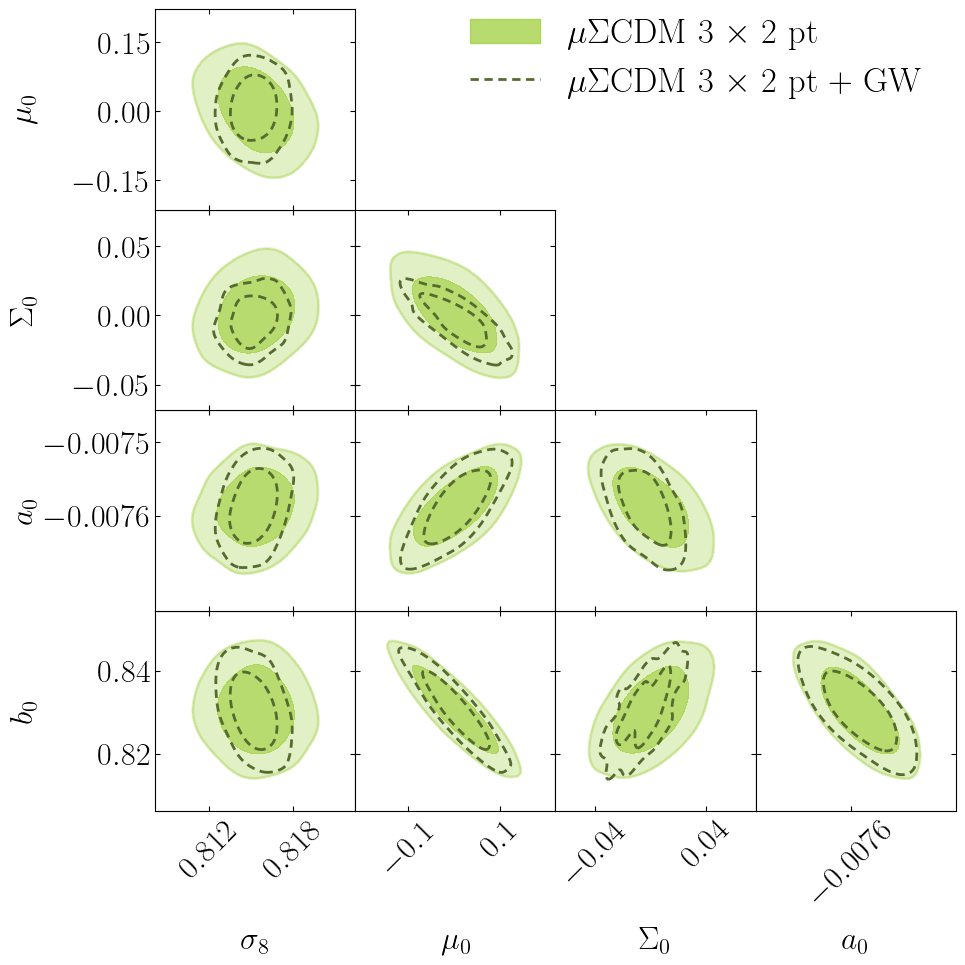

In [16]:
g = plots.get_subplot_plotter(subplot_size=1,width_inch=12, scaling=False)
g.settings.figure_legend_frame = False
g.settings.axes_fontsize = font_axes
g.settings.axes_labelsize = font_axes
g.settings.legend_fontsize = font_legend
g.settings.axis_marker_color = 'black'
g.settings.axis_marker_ls = '--'
g.settings.axis_marker_lw = 1
g.settings.axis_tick_x_rotation = 45

params = ['sigma8', 'mu0', 'sigma0', 'a0', 'b0_poly']

g.triangle_plot(
    [result['MCsamples'] for result in results_muSigma.values()],
    params,
    filled=[result['filled'] for result in results_muSigma.values()],
    legend_loc='upper right',
    legend_labels=list(results_muSigma.keys()),
    contour_colors=[result['color'] for result in results_muSigma.values()],
    contour_lws=2,
    alphas=[result['alpha'] for result in results_muSigma.values()],
    ls=[result['linestyle'] for result in results_muSigma.values()],
)

n = len(params)
for i in range(n):
    g.subplots[i, i].set_visible(False)

leg = g.fig.legends[0]
leg.set_bbox_to_anchor((0.78, 0.8))   
leg.set_loc("upper right")

g.fig.align_ylabels()
g.fig.align_xlabels()
plt.tight_layout()
plt.show()


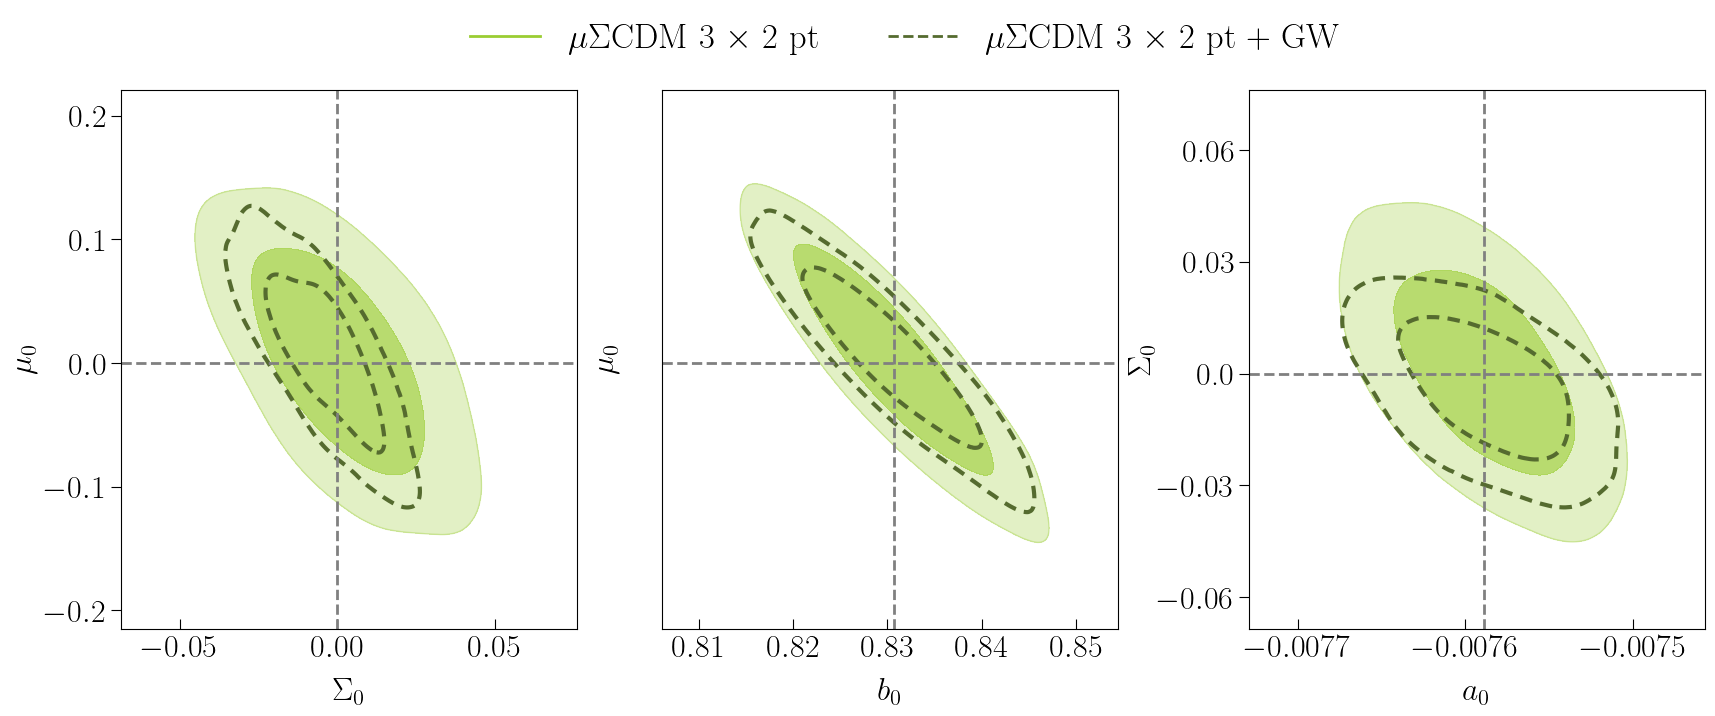

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

In [17]:
import matplotlib.lines as mlines
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20,7))
axes[1].sharey(axes[0])

plot_kwargs = dict(
    filled=[result['filled'] for result in results_muSigma.values()],
    colors=[result['color'] for result in results_muSigma.values()],
    lws=[0,3],
    alphas=[result['alpha'] for result in results_muSigma.values()],
    ls=[result['linestyle'] for result in results_muSigma.values()]
)

g = plots.get_single_plotter()
g.settings.figure_legend_frame = False
g.settings.legend_fontsize     = font_legend
g.settings.axes_fontsize       = font_axes
g.settings.axes_labelsize      = font_axes
g.plot_2d([result['MCsamples'] for result in results_muSigma.values()],
          ['sigma0', 'mu0'], ax=axes[0], **plot_kwargs)
g.add_x_marker(fiducial['sigma0'],lw=2,ax=axes[0])
g.add_y_marker(fiducial['mu0'],lw=2,ax=axes[0])
axes[0].tick_params(axis='y', which='both', left=True, labelleft=True)

pos = axes[0].get_position()
axes[0].set_position([pos.x0 - 0.017, pos.y0, pos.width, pos.height])

g = plots.get_single_plotter()
g.settings.figure_legend_frame = False
g.settings.legend_fontsize     = font_legend
g.settings.axes_fontsize       = font_axes
g.settings.axes_labelsize      = font_axes
g.plot_2d([result['MCsamples'] for result in results_muSigma.values()],
          ['b0_poly', 'mu0'], ax=axes[1], **plot_kwargs)

g.add_x_marker(fiducial['b0_poly'],lw=2,ax=axes[1])
g.add_y_marker(fiducial['mu0'],lw=2,ax=axes[1])
axes[1].tick_params(axis='y', left=False, labelleft=False)

axes[1].set_ylabel(r'$\mu_0$', labelpad=30)
axes[1].yaxis.set_label_position("left")

pos = axes[1].get_position()
axes[1].set_position([pos.x0 - 0.02, pos.y0, pos.width, pos.height])

g = plots.get_single_plotter()
g.settings.figure_legend_frame = False
g.settings.legend_fontsize     = font_legend
g.settings.axes_fontsize       = font_axes
g.settings.axes_labelsize      = font_axes
g.plot_2d([result['MCsamples'] for result in results_muSigma.values()],
          ['a0', 'sigma0'], ax=axes[2], **plot_kwargs)
axes[2].set_yticks([-0.06, -0.03 ,  0.0, 0.03, 0.06])
axes[2].set_yticklabels([r'$-0.06$', r'$-0.03$', '0.0', '0.03', '0.06'])


axes[2].set_ylabel(r'$\Sigma_0$', labelpad=1)
axes[2].yaxis.set_label_position("left")
g.add_x_marker(fiducial['a0'],lw=2,ax=axes[2])
g.add_y_marker(fiducial['sigma0'],lw=2,ax=axes[2])

labels = [result for result in results_muSigma.keys()]
colors = [result['color'] for result in results_muSigma.values()]
linestyles = [result['linestyle'] for result in results_muSigma.values()]

handles = [mlines.Line2D([], [], color=c, ls=ls, lw=2, label=lab)
           for c, ls, lab in zip(colors, linestyles, labels)]
axes[2].tick_params(axis='y', which='both', direction='out', length=7)
axes[0].tick_params(axis='y', which='both', direction='out', length=7)
axes[1].tick_params(axis='x', which='both', direction='in', length=7)
axes[0].tick_params(axis='x', which='both', direction='in', length=7)
axes[2].tick_params(axis='x', which='both', direction='in', length=7)

fig.legend(handles=handles, loc='upper center', ncol=len(labels),
           frameon=False, fontsize=font_legend, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


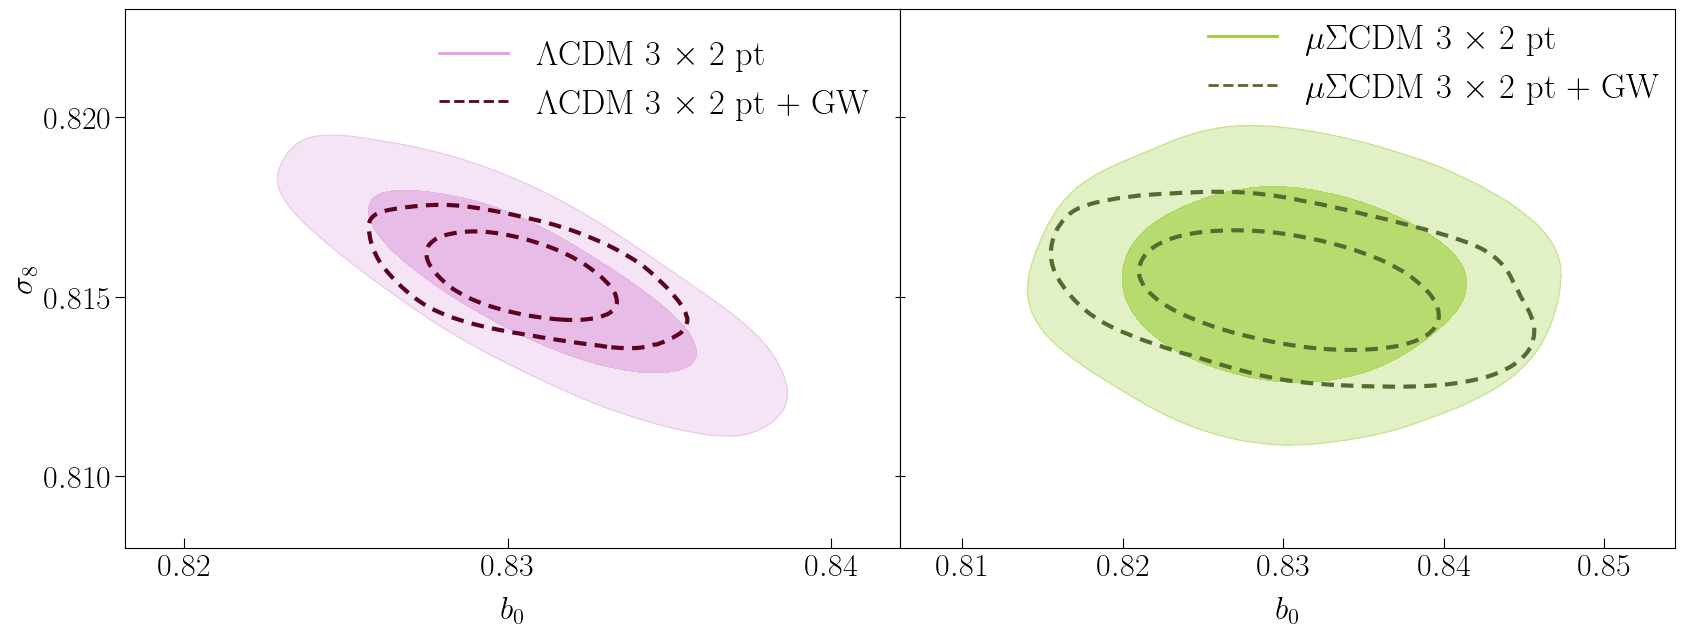

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

In [18]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from getdist import plots

fig, axes = plt.subplots(
    nrows=1, ncols=2, sharey=True,
    figsize=(20, 7),       
    gridspec_kw={"wspace": 0.0}  
)

g = plots.get_single_plotter()
g.settings.figure_legend_frame = False
g.settings.legend_fontsize     = 30
g.settings.axes_fontsize       = font_axes
g.settings.axes_labelsize      = font_axes

g.plot_2d(
    [res['MCsamples'] for res in results_LCDM.values()],
    ['b0_poly', 'sigma8'],
    ax=axes[0],
    filled=[res['filled'] for res in results_LCDM.values()],
    colors=[res['color'] for res in results_LCDM.values()],
    lws=[0,3],
    alphas=[res['alpha'] for res in results_LCDM.values()],
    ls=[res['linestyle'] for res in results_LCDM.values()],
)

handles_LCDM = [
    mlines.Line2D([], [], color=res['color'], lw=2, ls=res['linestyle'], label=name)
    for name, res in results_LCDM.items()
]
axes[0].legend(handles=handles_LCDM, loc='upper right', frameon=False, fontsize=font_legend)

axes[0].tick_params(axis='y', left=True, labelleft=True)


g = plots.get_single_plotter()
g.settings.figure_legend_frame = False
g.settings.legend_fontsize     = 30
g.settings.axes_fontsize       = font_axes
g.settings.axes_labelsize      = font_axes

g.plot_2d(
    [res['MCsamples'] for res in results_muSigma.values()],
    ['b0_poly', 'sigma8'],
    ax=axes[1],
    filled=[res['filled'] for res in results_muSigma.values()],
    colors=[res['color'] for res in results_muSigma.values()],
    lws=[0,3],
    alphas=[res['alpha'] for res in results_muSigma.values()],
    ls=[res['linestyle'] for res in results_muSigma.values()],
)

handles_muSigma = [
    mlines.Line2D([], [], color=res['color'], lw=2, ls=res['linestyle'], label=name)
    for name, res in results_muSigma.items()
]
axes[1].legend(handles=handles_muSigma, loc='upper right', bbox_to_anchor=(1.02, 1.03), frameon=False, fontsize=font_legend)

axes[1].set_ylabel("")                  
axes[1].tick_params(axis='y', which='both', direction='inout', length=7)
axes[0].tick_params(axis='y', which='both', direction='out', length=7)
axes[1].tick_params(axis='x', which='both', direction='in', length=7)
axes[0].tick_params(axis='x', which='both', direction='in', length=7)
axes[0].set_ylim(0.808, 0.823)

plt.tight_layout()
plt.show()


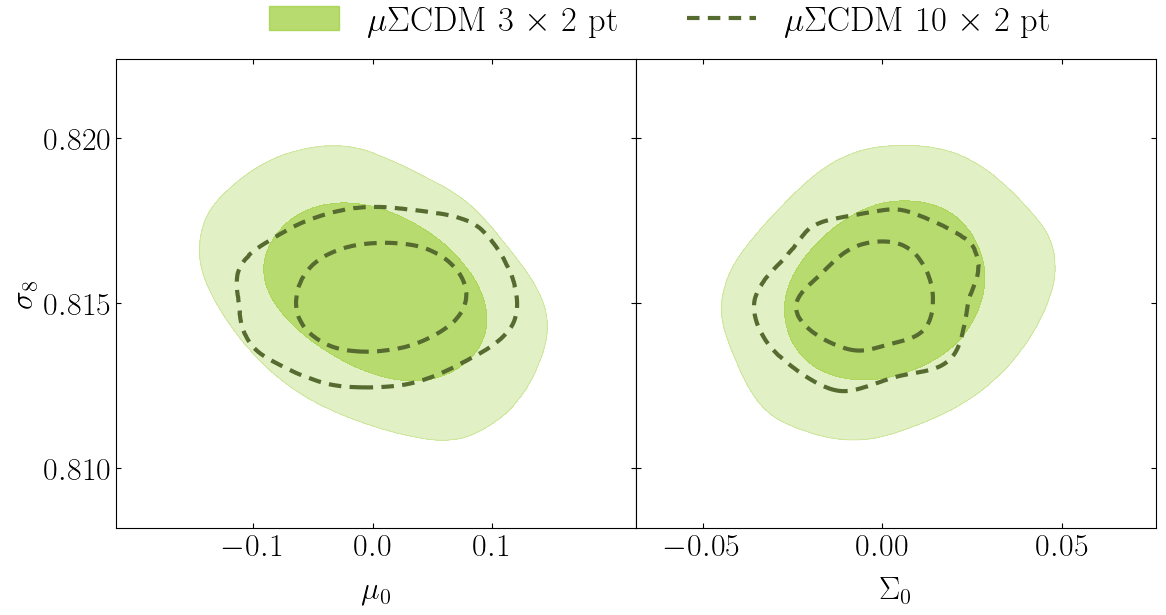

In [13]:
from getdist import plots

g = plots.get_subplot_plotter(subplot_size=1, width_inch=12, scaling=False)
g.settings.axes_fontsize = font_axes
g.settings.figure_legend_frame = False
g.settings.legend_fontsize = font_legend
g.settings.axes_labelsize = font_axes
g.rectangle_plot(
    ['mu0', 'sigma0'],
    'sigma8',
    roots=[result['MCsamples'] for result in results_muSigma.values()],
    colors=[result['color'] for result in results_muSigma.values()],
    filled=[result['filled'] for result in results_muSigma.values()],
    alphas=[result['alpha'] for result in results_muSigma.values()],
    ls=[result['linestyle'] for result in results_muSigma.values()],
    lws=[0,3]
)
leg = g.fig.legends[0]
leg.set_bbox_to_anchor((0.55, 0.94))   
plt.savefig("./Results/muSigma_sigma8.pdf", dpi=300, bbox_inches='tight')


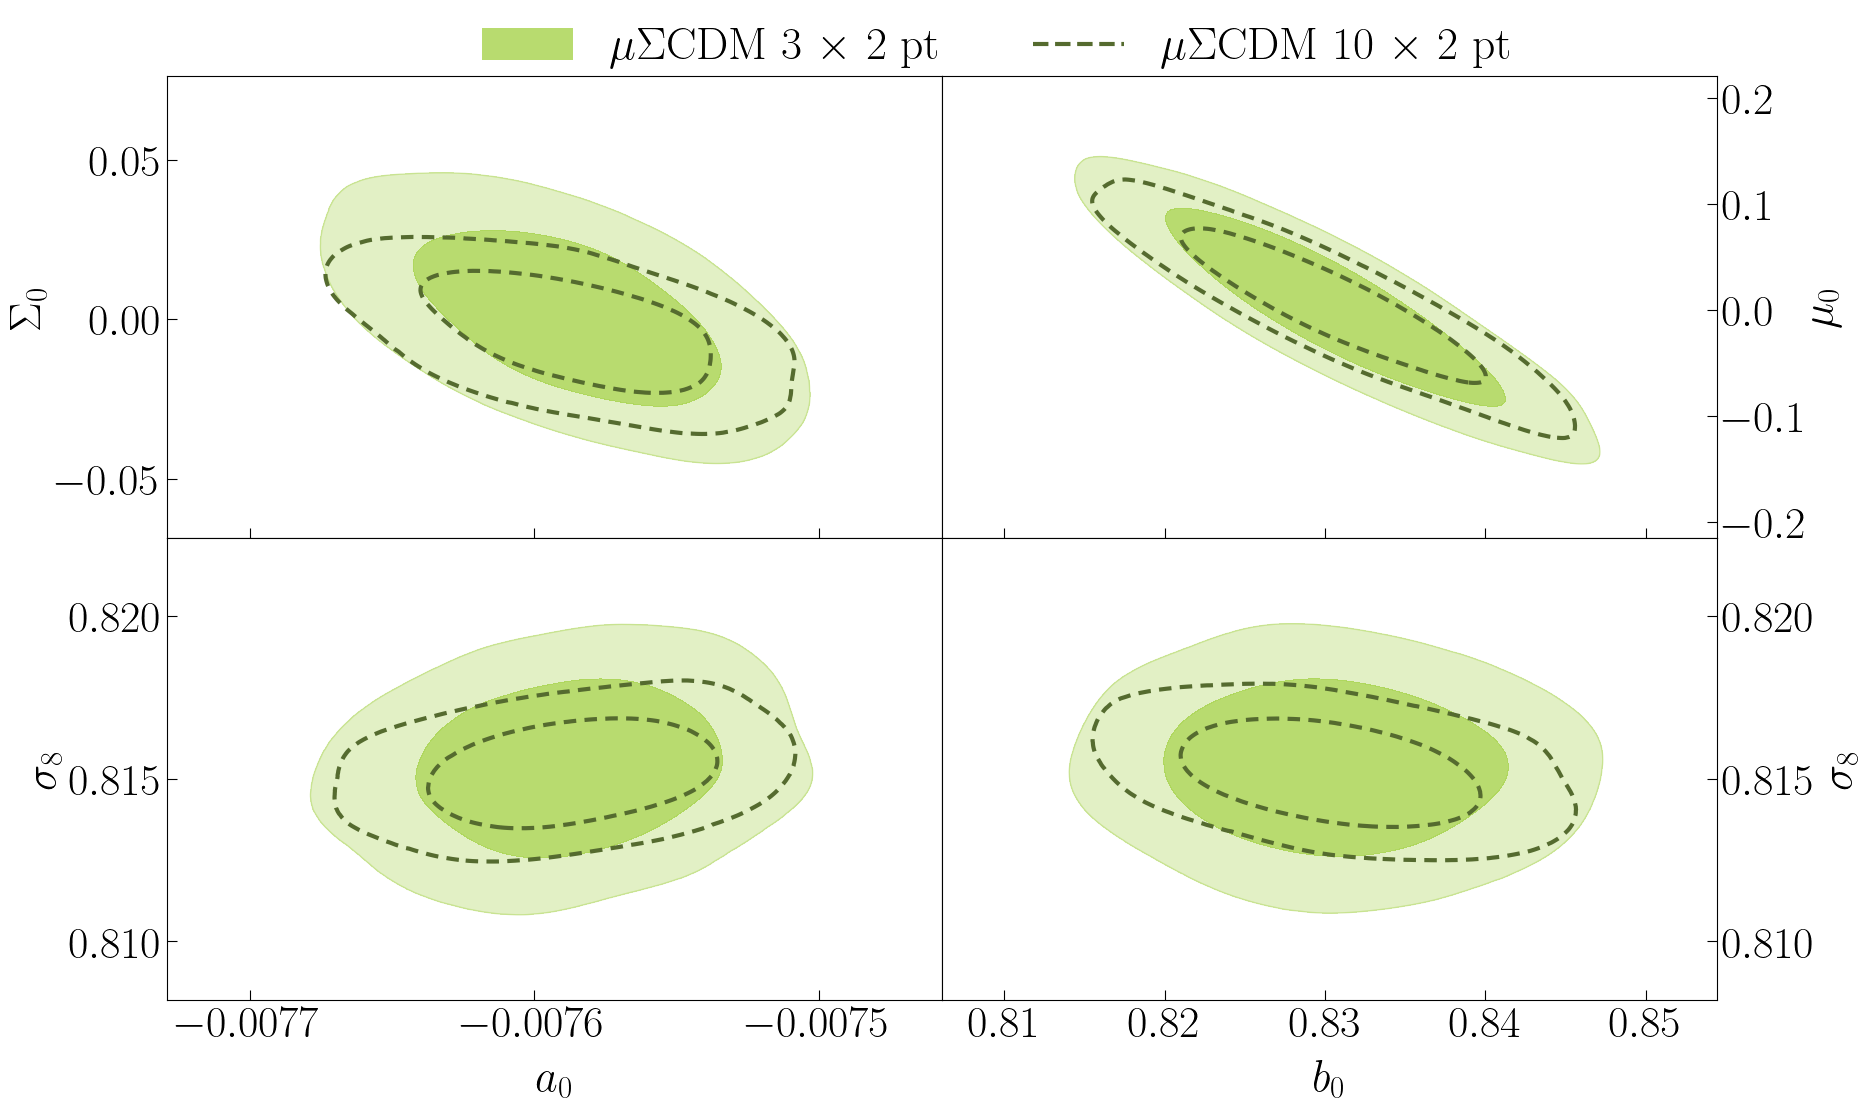

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

In [19]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from getdist import plots

fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(20, 12),
    gridspec_kw={"wspace": 0.0, "hspace": 0.0}
)

(ax11, ax12), (ax21, ax22) = axes

import matplotlib.patches as mpatches
import matplotlib.lines as mlines

legend_handles = []

for name, res in results_muSigma.items():
    if res["filled"]:
        # Filled square patch
        handle = mpatches.Patch(
            facecolor=res["color"],
            edgecolor="none",
            alpha=res["alpha"],
            label=name
        )
    else:
        # Line for unfilled contours
        handle = mlines.Line2D(
            [], [], 
            color=res["color"], 
            lw=3, 
            ls=res["linestyle"], 
            label=name
        )
    
    legend_handles.append(handle)


def cfg(g):
    g.settings.figure_legend_frame = False
    g.settings.legend_fontsize     = 40
    g.settings.axes_fontsize       = 29
    g.settings.axes_labelsize      = 29

g = plots.get_single_plotter()
cfg(g)
g.plot_2d(
    [res['MCsamples'] for res in results_muSigma.values()],
    ['a0', 'sigma0'],
    ax=ax11,
    filled=[res['filled'] for res in results_muSigma.values()],
    colors=[res['color'] for res in results_muSigma.values()],
    lws=[0,3],
    alphas=[res['alpha'] for res in results_muSigma.values()],
    ls=[res['linestyle'] for res in results_muSigma.values()],
)
ax11.set_ylabel(r'$\Sigma_0$', fontsize=32)
ax11.fontsize=30
ax11.labelsize=30
ax11.tick_params(axis='both', direction='in', length=7, labelsize=32)

g = plots.get_single_plotter()
cfg(g)
g.plot_2d(
    [res['MCsamples'] for res in results_muSigma.values()],
    ['b0_poly', 'mu0'],
    ax=ax12,
    filled=[res['filled'] for res in results_muSigma.values()],
    colors=[res['color'] for res in results_muSigma.values()],
    lws=[0,3],
    alphas=[res['alpha'] for res in results_muSigma.values()],
    ls=[res['linestyle'] for res in results_muSigma.values()],
)
ax12.set_ylabel(r'$\mu_0$', labelpad=-5, fontsize=32)
ax12.yaxis.set_label_position("right")
ax12.yaxis.tick_right()
ax12.fontsize=30
ax12.labelsize=30
ax12.tick_params(axis='both', direction='in', length=7, labelsize=32)

g = plots.get_single_plotter()
cfg(g)
g.plot_2d(
    [res['MCsamples'] for res in results_muSigma.values()],
    ['a0', 'sigma8'],
    ax=ax21,
    filled=[res['filled'] for res in results_muSigma.values()],
    colors=[res['color'] for res in results_muSigma.values()],
    lws=[0,3],
    alphas=[res['alpha'] for res in results_muSigma.values()],
    ls=[res['linestyle'] for res in results_muSigma.values()],
)
ax21.set_ylabel(r'$\sigma_8$', fontsize=32)
ax21.set_xlabel(r'$ a_0$', fontsize=32)
ax21.fontsize=30
ax21.labelsize=30
ax21.tick_params(axis='both', direction='in', length=7 , labelsize=32)

g = plots.get_single_plotter()
cfg(g)
g.plot_2d(
    [res['MCsamples'] for res in results_muSigma.values()],
    ['b0_poly', 'sigma8'],
    ax=ax22,
    filled=[res['filled'] for res in results_muSigma.values()],
    colors=[res['color'] for res in results_muSigma.values()],
    lws=[0,3],
    alphas=[res['alpha'] for res in results_muSigma.values()],
    ls=[res['linestyle'] for res in results_muSigma.values()],
)
ax22.set_ylabel(r'$\sigma_8$', fontsize=32)
ax22.set_xlabel(r'$ b_0$', fontsize=32)
ax22.tick_params(axis='both', direction='in', length=7, labelsize=32)
ax22.yaxis.set_label_position("right")
ax22.yaxis.tick_right()
ax22.fontsize=30
ax22.labelsize=30
ax22.tick_params(axis='both', direction='in', length=7, labelsize=32)

for ax in ax11, ax12:
    ax.tick_params(axis='x', labelbottom=False)

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.54, 0.955),
    ncol=len(legend_handles),
    frameon=False,
    fontsize=33
)
fig.savefig("./Results/muSigma_sigma8_nuis.pdf", dpi=300, bbox_inches="tight")


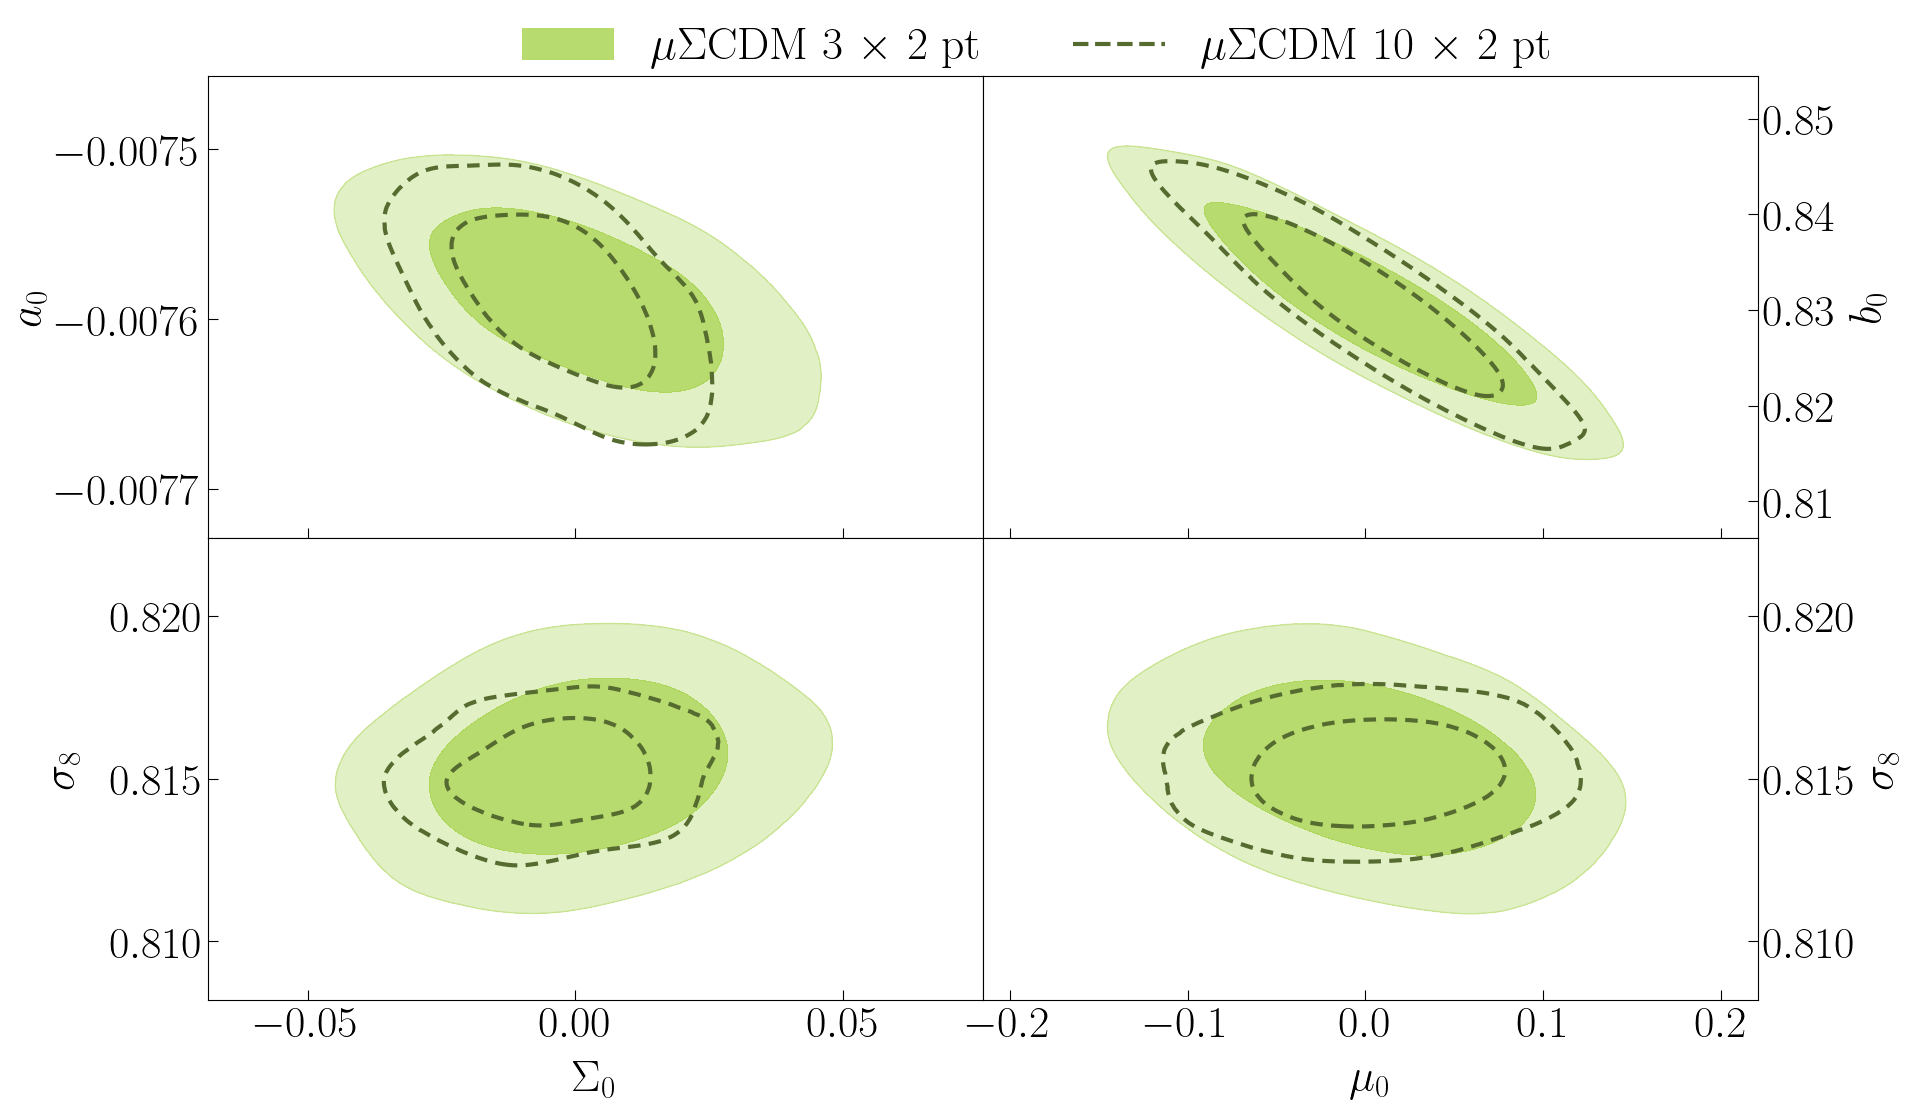

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

In [29]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from getdist import plots

fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(20, 12),
    gridspec_kw={"wspace": 0.0, "hspace": 0.0}
)

(ax11, ax12), (ax21, ax22) = axes

import matplotlib.patches as mpatches
import matplotlib.lines as mlines

legend_handles = []

for name, res in results_muSigma.items():
    if res["filled"]:
        # Filled square patch
        handle = mpatches.Patch(
            facecolor=res["color"],
            edgecolor="none",
            alpha=res["alpha"],
            label=name
        )
    else:
        # Line for unfilled contours
        handle = mlines.Line2D(
            [], [], 
            color=res["color"], 
            lw=3, 
            ls=res["linestyle"], 
            label=name
        )
    
    legend_handles.append(handle)


def cfg(g):
    g.settings.figure_legend_frame = False
    g.settings.legend_fontsize     = 40
    g.settings.axes_fontsize       = 29
    g.settings.axes_labelsize      = 29

g = plots.get_single_plotter()
cfg(g)
g.plot_2d(
    [res['MCsamples'] for res in results_muSigma.values()],
    ['sigma0', 'a0'],
    ax=ax11,
    filled=[res['filled'] for res in results_muSigma.values()],
    colors=[res['color'] for res in results_muSigma.values()],
    lws=[0,3],
    alphas=[res['alpha'] for res in results_muSigma.values()],
    ls=[res['linestyle'] for res in results_muSigma.values()],
)
ax11.set_ylabel(r'$a_0$', fontsize=32)
ax11.fontsize=30
ax11.labelsize=30
ax11.tick_params(axis='both', direction='in', length=7, labelsize=32)

g = plots.get_single_plotter()
cfg(g)
g.plot_2d(
    [res['MCsamples'] for res in results_muSigma.values()],
    [ 'mu0', 'b0_poly'],
    ax=ax12,
    filled=[res['filled'] for res in results_muSigma.values()],
    colors=[res['color'] for res in results_muSigma.values()],
    lws=[0,3],
    alphas=[res['alpha'] for res in results_muSigma.values()],
    ls=[res['linestyle'] for res in results_muSigma.values()],
)
ax12.set_ylabel(r'$b_0$', labelpad=10, fontsize=32)
ax12.yaxis.set_label_position("right")
ax12.yaxis.tick_right()
ax12.fontsize=30
ax12.labelsize=30
ax12.tick_params(axis='both', direction='in', length=7, labelsize=32)

g = plots.get_single_plotter()
cfg(g)
g.plot_2d(
    [res['MCsamples'] for res in results_muSigma.values()],
    ['sigma0', 'sigma8'],
    ax=ax21,
    filled=[res['filled'] for res in results_muSigma.values()],
    colors=[res['color'] for res in results_muSigma.values()],
    lws=[0,3],
    alphas=[res['alpha'] for res in results_muSigma.values()],
    ls=[res['linestyle'] for res in results_muSigma.values()],
)
ax21.set_ylabel(r'$\sigma_8$', labelpad=20,fontsize=32)
ax21.set_xlabel(r'$\Sigma_0$', fontsize=32)
ax21.fontsize=30
ax21.labelsize=30
ax21.tick_params(axis='both', direction='in', length=7 , labelsize=32)

g = plots.get_single_plotter()
cfg(g)
g.plot_2d(
    [res['MCsamples'] for res in results_muSigma.values()],
    ['mu0', 'sigma8'],
    ax=ax22,
    filled=[res['filled'] for res in results_muSigma.values()],
    colors=[res['color'] for res in results_muSigma.values()],
    lws=[0,3],
    alphas=[res['alpha'] for res in results_muSigma.values()],
    ls=[res['linestyle'] for res in results_muSigma.values()],
)
ax22.set_ylabel(r'$\sigma_8$', fontsize=32)
ax22.set_xlabel(r'$ \mu_0$', fontsize=32)
ax22.tick_params(axis='both', direction='in', length=7, labelsize=32)
ax22.yaxis.set_label_position("right")
ax22.yaxis.tick_right()
ax22.fontsize=30
ax22.labelsize=30
ax22.tick_params(axis='both', direction='in', length=7, labelsize=32)

for ax in ax11, ax12:
    ax.tick_params(axis='x', labelbottom=False)

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.54, 0.955),
    ncol=len(legend_handles),
    frameon=False,
    fontsize=33
)
fig.savefig("./Results/muSigma_sigma8_b0a0.pdf", dpi=300, bbox_inches="tight")


In [21]:
results_tot = results_muSigma | results_LCDM

In [47]:
results_tot['$\\Lambda$CDM 10 $\\times$ 2 pt ']['linestyle'] = '-'

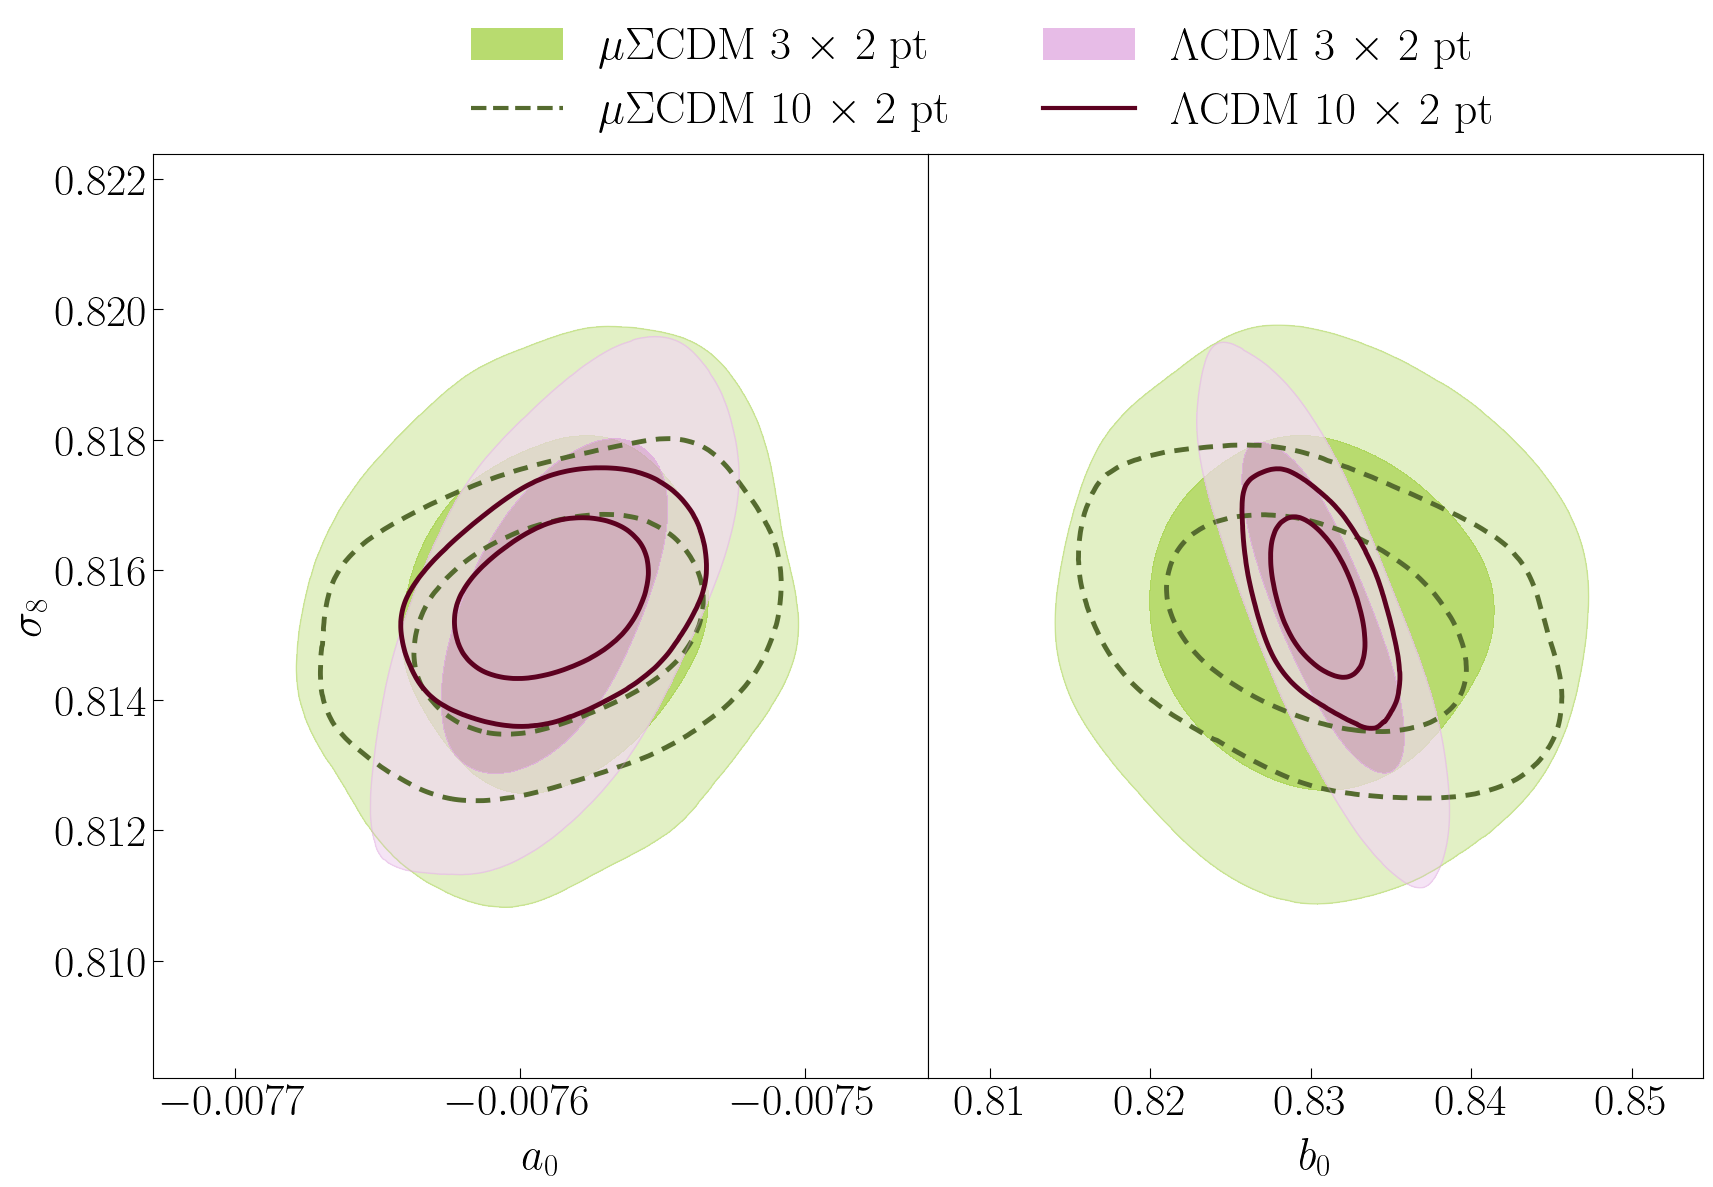

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

In [49]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from getdist import plots

fig, axes = plt.subplots(
    nrows=1, ncols=2,
    figsize=(20, 12),
    gridspec_kw={"wspace": 0.0, "hspace": 0.0}
)

(ax11, ax12)= axes

import matplotlib.patches as mpatches
import matplotlib.lines as mlines

legend_handles = []

for name, res in results_tot.items():
    if res["filled"]:
        # Filled square patch
        handle = mpatches.Patch(
            facecolor=res["color"],
            edgecolor="none",
            alpha=res["alpha"],
            label=name
        )
    else:
        # Line for unfilled contours
        handle = mlines.Line2D(
            [], [], 
            color=res["color"], 
            lw=3, 
            ls=res["linestyle"], 
            label=name
        )
    
    legend_handles.append(handle)

def cfg(g):
    g.settings.figure_legend_frame = False
    g.settings.legend_fontsize     = 40
    g.settings.axes_fontsize       = 29
    g.settings.axes_labelsize      = 29

g = plots.get_single_plotter()
cfg(g)
g.plot_2d(
    [res['MCsamples'] for res in results_tot.values()],
    ['a0', 'sigma8'],
    ax=ax11,
    filled=[res['filled'] for res in results_tot.values()],
    colors=[res['color'] for res in results_tot.values()],
    lws=[0,3.5,0,3.5],
    alphas=[res['alpha'] for res in results_tot.values()],
    ls=['-', '--', '-', '-']#[res['linestyle'] for res in results_tot.values()],
)
ax11.set_ylabel(r'$\sigma_8$', fontsize=32)
ax11.tick_params(axis='both', direction='in', length=7, labelsize=32)
ax11.set_xlabel(r'$ a_0$', fontsize=32)
ax11.fontsize=30
ax11.labelsize=35


g = plots.get_single_plotter()
cfg(g)
g.plot_2d(
    [res['MCsamples'] for res in results_tot.values()],
    ['b0_poly', 'sigma8'],
    ax=ax12,
    filled=[res['filled'] for res in results_tot.values()],
    colors=[res['color'] for res in results_tot.values()],
    lws=[0,3.5,0,3.5],
    alphas=[res['alpha'] for res in results_tot.values()],
    ls=['-', '--', '-', '-']#[res['linestyle'] for res in results_tot.values()],
)
ax12.set_ylabel("")
ax12.tick_params(axis='both', direction='in', length=7, labelsize=32)
ax12.set_xlabel(r'$ b_0$', fontsize=32)
ax12.yaxis.set_ticks([])
fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.54, 1.02),
    ncol=len(legend_handles)/2,
    frameon=False,
    fontsize=33
)
fig.savefig("./Results/sigma8_nuis_all.pdf", dpi=300, bbox_inches='tight')


## Correlation matrix


In [71]:
covmat_LCDM_3x2pt = results_LCDM['$\\Lambda$CDM 3 $\\times$ 2 pt ']['MCsamples'].getCovMat()
names = covmat_LCDM_3x2pt.paramNames
corr = covmat_LCDM_3x2pt.correlation()

strong_corr_LCDM_3x2pt = {}  

print("Strong correlations (|corr| > 0.5):\n" + "-"*40)
for i in range(corr.shape[0]):
    for j in range(i+1, corr.shape[1]):
        value = corr[i, j]
        if 0.1 < abs(value) < 1.0:
            p1 = names[i]
            p2 = names[j]
            
            # save to dict
            strong_corr_LCDM_3x2pt[(p1, p2)] = float(value)
            
            relation = "↑" if value > 0 else "↓"
            print(f"{p1:<20} vs {p2:<20}: {value:6.3f}  "
                  f"({'positive' if value > 0 else 'negative'} {relation})")




Strong correlations (|corr| > 0.5):
----------------------------------------
ombh2                vs omch2               :  0.911  (positive ↑)
ombh2                vs ns                  : -0.687  (negative ↓)
ombh2                vs H0                  :  0.943  (positive ↑)
ombh2                vs logA                : -0.762  (negative ↓)
ombh2                vs a0                  :  0.151  (positive ↑)
ombh2                vs a2                  : -0.140  (negative ↓)
ombh2                vs As                  : -0.761  (negative ↓)
ombh2                vs omegab              :  0.918  (positive ↑)
ombh2                vs omegam              : -0.128  (negative ↓)
ombh2                vs sigma8              :  0.245  (positive ↑)
omch2                vs ns                  : -0.912  (negative ↓)
omch2                vs H0                  :  0.991  (positive ↑)
omch2                vs logA                : -0.956  (negative ↓)
omch2                vs a0                  :  0.242

In [72]:
covmat_LCDM_3x2pt_GW = results_LCDM['$\\Lambda$CDM 3 $\\times$ 2 pt + GW ']['MCsamples'].getCovMat()
names = covmat_LCDM_3x2pt_GW.paramNames
corr = covmat_LCDM_3x2pt_GW.correlation()

strong_corr_LCDM_3x2pt_GW = {}  

print("Strong correlations (|corr| > 0.5):\n" + "-"*40)
for i in range(corr.shape[0]):
    for j in range(i+1, corr.shape[1]):
        value = corr[i, j]
        if 0.2 < abs(value) < 1.0:
            p1 = names[i]
            p2 = names[j]
            
            # save to dict
            strong_corr_LCDM_3x2pt_GW[(p1, p2)] = float(value)
            
            relation = "↑" if value > 0 else "↓"
            print(f"{p1:<20} vs {p2:<20}: {value:6.3f}  "
                  f"({'positive' if value > 0 else 'negative'} {relation})")

Strong correlations (|corr| > 0.5):
----------------------------------------
ombh2                vs omch2               :  0.860  (positive ↑)
ombh2                vs ns                  : -0.476  (negative ↓)
ombh2                vs H0                  :  0.928  (positive ↑)
ombh2                vs logA                : -0.582  (negative ↓)
ombh2                vs b0_poly             : -0.346  (negative ↓)
ombh2                vs As                  : -0.581  (negative ↓)
ombh2                vs omegab              :  0.924  (positive ↑)
ombh2                vs omegam              : -0.616  (negative ↓)
ombh2                vs sigma8              :  0.607  (positive ↑)
omch2                vs ns                  : -0.829  (negative ↓)
omch2                vs H0                  :  0.986  (positive ↑)
omch2                vs logA                : -0.912  (negative ↓)
omch2                vs b0_poly             : -0.297  (negative ↓)
omch2                vs As                  : -0.911

In [118]:
print(results_muSigma.keys())

dict_keys(['$\\mu\\Sigma$CDM 3 $\\times$ 2 pt', '$\\mu\\Sigma$CDM  3 $\\times$ 2 pt + GW '])


In [143]:
covmat_muSigmaCDM_3x2pt = results_muSigma['$\\mu\\Sigma$CDM 3 $\\times$ 2 pt']['MCsamples'].getCovMat()
names = covmat_muSigmaCDM_3x2pt.paramNames
corr = covmat_muSigmaCDM_3x2pt.correlation()

strong_corr_muSigmaCDM_3x2pt = {}  

print("Strong correlations (|corr| > 0.5):\n" + "-"*40)
for i in range(corr.shape[0]):
    for j in range(i+1, corr.shape[1]):
        value = corr[i, j]
        if 0.0 < abs(value) < 1.0:
            p1 = names[i]
            p2 = names[j]
            
            # save to dict
            strong_corr_muSigmaCDM_3x2pt[(p1, p2)] = float(value)
            
            relation = "↑" if value > 0 else "↓"
            print(f"{p1:<20} vs {p2:<20}: {value:6.3f}  "
                  f"({'positive' if value > 0 else 'negative'} {relation})")




Strong correlations (|corr| > 0.5):
----------------------------------------
ombh2                vs omch2               :  0.900  (positive ↑)
ombh2                vs ns                  : -0.639  (negative ↓)
ombh2                vs H0                  :  0.899  (positive ↑)
ombh2                vs logA                : -0.742  (negative ↓)
ombh2                vs a0                  :  0.101  (positive ↑)
ombh2                vs a1                  : -0.052  (negative ↓)
ombh2                vs a2                  : -0.044  (negative ↓)
ombh2                vs a3                  : -0.018  (negative ↓)
ombh2                vs a4                  :  0.043  (positive ↑)
ombh2                vs b0_poly             : -0.106  (negative ↓)
ombh2                vs b1_poly             : -0.014  (negative ↓)
ombh2                vs b2_poly             :  0.047  (positive ↑)
ombh2                vs b3_poly             : -0.052  (negative ↓)
ombh2                vs mu0                 :  0.060

In [123]:
covmat_muSigmaCDM_3x2pt_GW = results_muSigma['$\\mu\\Sigma$CDM  3 $\\times$ 2 pt + GW ']['MCsamples'].getCovMat()
names = covmat_muSigmaCDM_3x2pt_GW.paramNames
corr = covmat_muSigmaCDM_3x2pt_GW.correlation()

strong_corr_muSigmaCDM_3x2pt_GW = {}  

print("Strong correlations (|corr| > 0.5):\n" + "-"*40)
for i in range(corr.shape[0]):
    for j in range(i+1, corr.shape[1]):
        value = corr[i, j]
        if 0.01 < abs(value) < 1.0:
            p1 = names[i]
            p2 = names[j]
            
            # save to dict
            strong_corr_muSigmaCDM_3x2pt_GW[(p1, p2)] = float(value)
            
            relation = "↑" if value > 0 else "↓"
            print(f"{p1:<20} vs {p2:<20}: {value:6.3f}  "
                  f"({'positive' if value > 0 else 'negative'} {relation})")




Strong correlations (|corr| > 0.5):
----------------------------------------
ombh2                vs omch2               :  0.888  (positive ↑)
ombh2                vs ns                  : -0.590  (negative ↓)
ombh2                vs H0                  :  0.921  (positive ↑)
ombh2                vs logA                : -0.731  (negative ↓)
ombh2                vs a0                  :  0.016  (positive ↑)
ombh2                vs a1                  :  0.019  (positive ↑)
ombh2                vs a4                  : -0.014  (negative ↓)
ombh2                vs b0_poly             : -0.055  (negative ↓)
ombh2                vs b1_poly             :  0.028  (positive ↑)
ombh2                vs b2_poly             : -0.015  (negative ↓)
ombh2                vs b3_poly             :  0.016  (positive ↑)
ombh2                vs b1_poly_GW          : -0.017  (negative ↓)
ombh2                vs b2_poly_GW          :  0.016  (positive ↑)
ombh2                vs b3_poly_GW          : -0.012

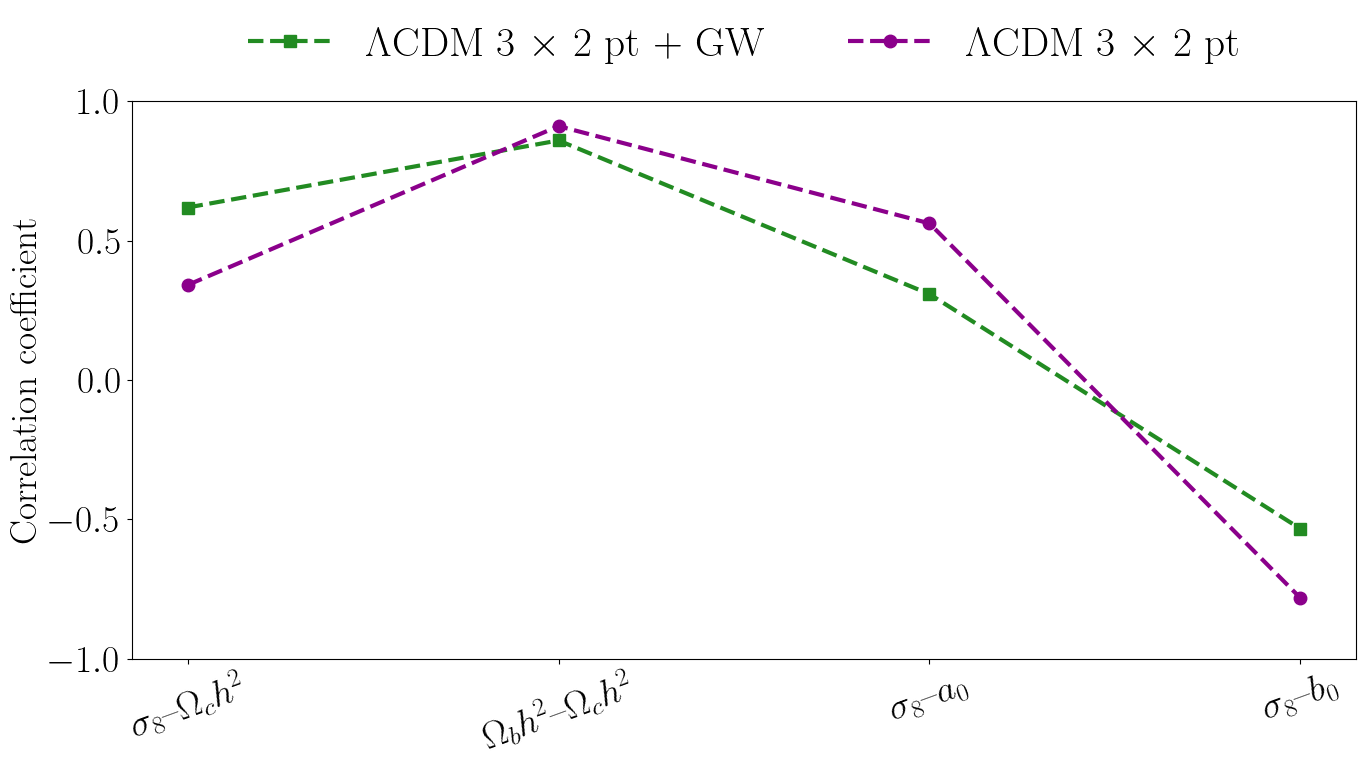

In [113]:
import matplotlib.pyplot as plt
latex_map = {
    "sigma8":    r"$\sigma_8$",
    "omch2":     r"$\Omega_c h^2$",
    "ombh2":     r"$\Omega_b h^2$",
    "a0":        r"$a_0$",
    "b0_poly":   r"$b_0$"
}

# --- choose the parameter pairs you want to plot ---
pairs = [
    ("sigma8", "omch2"),
    ("ombh2", "omch2"),
    ("sigma8", "a0"),
    ("sigma8", "b0_poly")
]

# extract the correlations for each pair from your dictionaries
vals_3x2   = []
vals_3x2GW = []

for p1, p2 in pairs:
    key1 = (p1, p2)
    key2 = (p2, p1)
    
    vals_3x2.append(
        strong_corr_LCDM_3x2pt.get(key1, strong_corr_LCDM_3x2pt.get(key2, None))
    )
    vals_3x2GW.append(
        strong_corr_LCDM_3x2pt_GW.get(key1, strong_corr_LCDM_3x2pt_GW.get(key2, None))
    )

# x positions
x = range(len(pairs))

# --- PLOT ---
plt.figure(figsize=(14,8))

# Colors consistent with your FoM (adjust if needed)
color_3x2   = "darkmagenta"      # or your exact pink shade
color_3x2GW = "forestgreen"       # or your exact bordeaux
plt.plot(
    x, vals_3x2GW, 
    marker='s', markersize=9, linestyle='--', linewidth=3,
    color=color_3x2GW, label=r'$\Lambda$CDM 3 $\times$ 2 pt + GW '
)

plt.plot(
    x, vals_3x2, 
    marker='o', markersize=9, linestyle='--', linewidth=3,
    color=color_3x2, label=r'$\Lambda$CDM 3 $\times$ 2 pt '

)


# x labels
labels = [f"{latex_map[p1]}–{latex_map[p2]}" for p1, p2 in pairs]
plt.xticks(x, labels, rotation=20, fontsize=27)
plt.yticks([-1, -0.5, 0, 0.5, 1], fontsize=27)
plt.ylabel("Correlation coefficient", fontsize=27)
plt.ylim(-1, 1)

plt.legend(
    fontsize=30,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=2,
    frameon=False
)
plt.tight_layout()
plt.show()


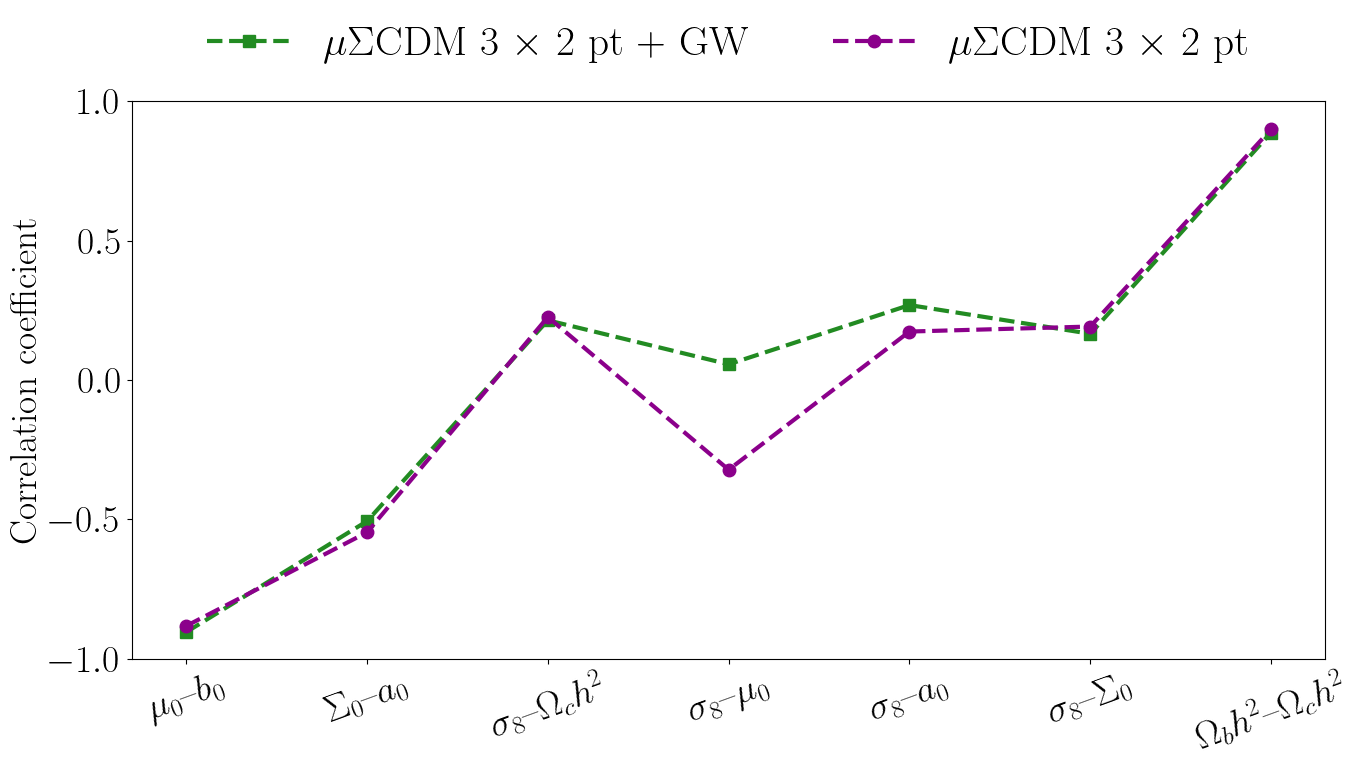

In [142]:
import matplotlib.pyplot as plt
latex_map = {
    "sigma8":    r"$\sigma_8$",
    "omch2":     r"$\Omega_c h^2$",
    "ombh2":     r"$\Omega_b h^2$",
    "a0":        r"$a_0$",
    "b0_poly":   r"$b_0$",
    "mu0":       r"$\mu_0$",
    "sigma0":    r"$\Sigma_0$"
}

# --- choose the parameter pairs you want to plot ---
pairs = [
    ("mu0", "b0_poly"),
    ("sigma0", "a0"),
    ("sigma8", "omch2"),
    ("sigma8", "mu0"),
    ("sigma8", "a0"),
    ("sigma8", "sigma0"),
    ("ombh2", "omch2"),
]

# extract the correlations for each pair from your dictionaries
vals_3x2   = []
vals_3x2GW = []

for p1, p2 in pairs:
    key1 = (p1, p2)
    key2 = (p2, p1)
    
    vals_3x2.append(
        strong_corr_muSigmaCDM_3x2pt.get(key1, strong_corr_muSigmaCDM_3x2pt.get(key2, None))
    )
    vals_3x2GW.append(
        strong_corr_muSigmaCDM_3x2pt_GW.get(key1, strong_corr_muSigmaCDM_3x2pt_GW.get(key2, None))
    )

# x positions
x = range(len(pairs))

# --- PLOT ---
plt.figure(figsize=(14,8))

# Colors consistent with your FoM (adjust if needed)
color_3x2   = "darkmagenta"      # or your exact pink shade
color_3x2GW = "forestgreen"       # or your exact bordeaux
plt.plot(
    x, vals_3x2GW, 
    marker='s', markersize=9, linestyle='--', linewidth=3,
    color=color_3x2GW, label=r'$\mu\Sigma$CDM 3 $\times$ 2 pt + GW '
)

plt.plot(
    x, vals_3x2, 
    marker='o', markersize=9, linestyle='--', linewidth=3,
    color=color_3x2, label=r'$\mu\Sigma$CDM 3 $\times$ 2 pt '

)


# x labels
labels = [f"{latex_map[p1]}–{latex_map[p2]}" for p1, p2 in pairs]
plt.xticks(x, labels, rotation=20, fontsize=27)
plt.yticks([-1, -0.5, 0, 0.5, 1], fontsize=27)
plt.ylabel("Correlation coefficient", fontsize=27)
plt.ylim(-1, 1)

plt.legend(
    fontsize=30,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=2,
    frameon=False
)
plt.tight_layout()
plt.show()


In [139]:
import numpy as np

def compute_fom(covmat, names, pair):
    p1, p2 = pair
    i = names.index(p1)
    j = names.index(p2)

    C = covmat.matrix

    subcov = np.array([
        [C[i, i], C[i, j]],
        [C[j, i], C[j, j]]
    ])

    det = np.linalg.det(subcov)
    return 1.0 / np.sqrt(det)

pairs = [
    ("mu0", "b0_poly"),
    ("sigma0", "a0"),
    ("sigma8", "omch2"),
    ("sigma8", "mu0"),
    ("sigma8", "a0"),
    ("sigma8", "sigma0"),
    ("ombh2", "omch2"),
    ("sigma8", "b0_poly")
]

FoM_LCDM_3x2   = {}
FoM_LCDM_3x2GW = {}
FoM_muSigma_3x2   = {}
FoM_muSigma_3x2GW = {}

cov_3x2   = results_LCDM['$\\Lambda$CDM 3 $\\times$ 2 pt ']['MCsamples'].getCovMat()
cov_3x2GW = results_LCDM['$\\Lambda$CDM 3 $\\times$ 2 pt + GW ']['MCsamples'].getCovMat()
cov_3x2muSigma   = results_muSigma['$\\mu\\Sigma$CDM 3 $\\times$ 2 pt']['MCsamples'].getCovMat()
cov_3x2muSigmaGW = results_muSigma['$\\mu\\Sigma$CDM  3 $\\times$ 2 pt + GW ']['MCsamples'].getCovMat()

names_3x2   = list(cov_3x2.paramNames)
names_3x2GW = list(cov_3x2GW.paramNames)
names_3x2muSigma   = list(cov_3x2muSigma.paramNames)
names_3x2muSigmaGW = list(cov_3x2muSigmaGW.paramNames)

for pair in pairs:
    try:
        FoM_LCDM_3x2[pair]   = compute_fom(cov_3x2, names_3x2, pair)
        FoM_LCDM_3x2GW[pair] = compute_fom(cov_3x2GW, names_3x2GW, pair)
    except ValueError:
        print("Could not compute FoM for pair:", pair)
    try:

        FoM_muSigma_3x2[pair]   = compute_fom(cov_3x2muSigma, names_3x2muSigma, pair)
        FoM_muSigma_3x2GW[pair] = compute_fom(cov_3x2muSigmaGW, names_3x2muSigmaGW, pair)
    except ValueError:
        print("Could not compute FoM for pair:", pair)


print("FoM 3×2:", FoM_LCDM_3x2)
print("FoM 3×2 + GW:", FoM_LCDM_3x2GW)



Could not compute FoM for pair: ('mu0', 'b0_poly')
Could not compute FoM for pair: ('sigma0', 'a0')
Could not compute FoM for pair: ('sigma8', 'mu0')
Could not compute FoM for pair: ('sigma8', 'sigma0')
FoM 3×2: {('sigma8', 'omch2'): 134180.0195520093, ('sigma8', 'a0'): 27056372.628455702, ('ombh2', 'omch2'): 303054.4501712769, ('sigma8', 'b0_poly'): 288605.28597638354}
FoM 3×2 + GW: {('sigma8', 'omch2'): 492595.5934031556, ('sigma8', 'a0'): 59430387.33300211, ('ombh2', 'omch2'): 465753.99676669564, ('sigma8', 'b0_poly'): 737939.9224112771}


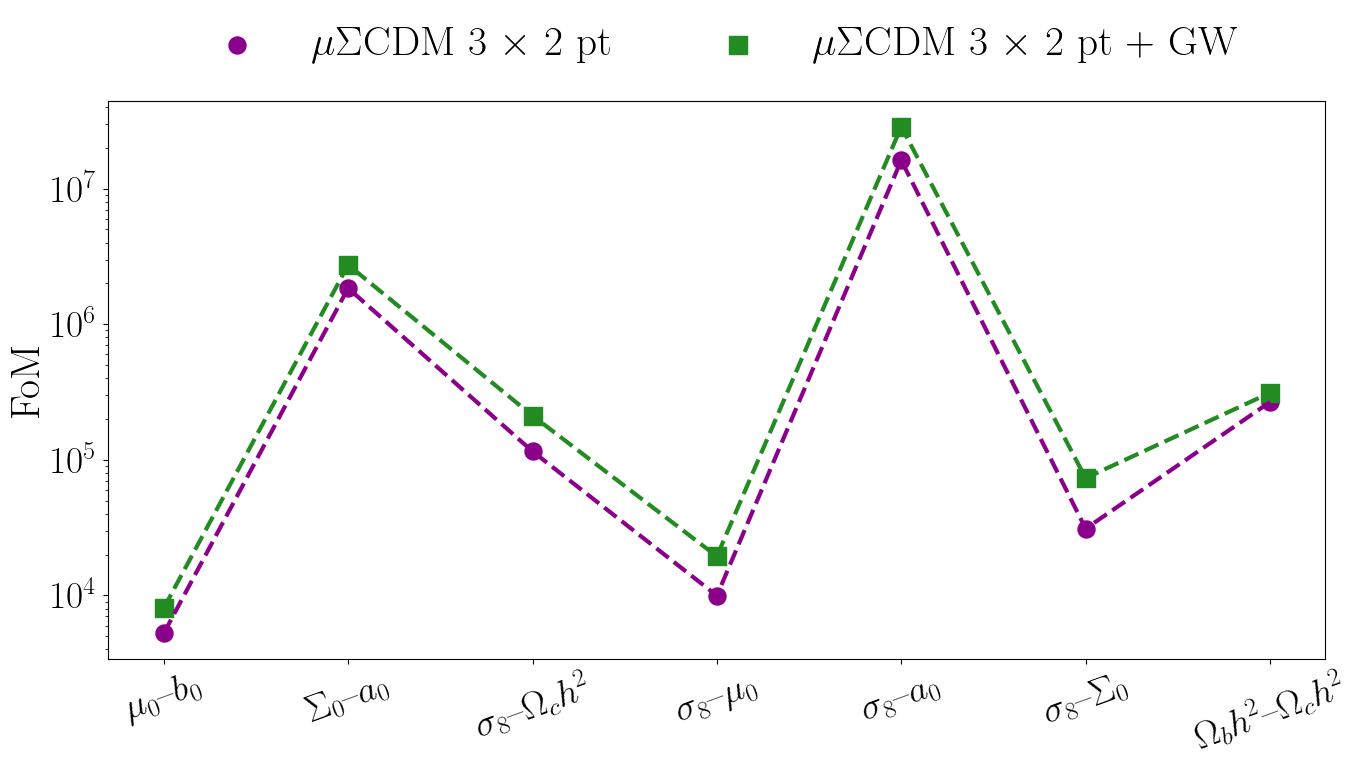

In [140]:
import matplotlib.pyplot as plt
import numpy as np


pairs_labels = [
    r"$\mu_0$–$b_0$",
    r"$\Sigma_0$–$a_0$",
    r"$\sigma_8$–$\Omega_c h^2$",
    r"$\sigma_8$–$\mu_0$",
    r"$\sigma_8$–$a_0$",
    r"$\sigma_8$–$\Sigma_0$",
    r"$\Omega_b h^2$–$\Omega_c h^2$"

]
pairs = [
    ("mu0", "b0_poly"),
    ("sigma0", "a0"),
    ("sigma8", "omch2"),
    ("sigma8", "mu0"),
    ("sigma8", "a0"),
    ("sigma8", "sigma0"),
    ("ombh2", "omch2"),
]
FoM_3x2   = np.array([FoM_muSigma_3x2[p] for p in pairs])
FoM_3x2GW = np.array([FoM_muSigma_3x2GW[p] for p in pairs])

x = np.arange(len(pairs))

plt.figure(figsize=(14,8))

# --- Points ---
plt.scatter(x, FoM_3x2,   s=150, marker="o", color="darkmagenta",  label=r'$\mu\Sigma$CDM 3 $\times$ 2 pt ')
plt.scatter(x, FoM_3x2GW, s=150, marker="s", color="forestgreen", label=r'$\mu\Sigma$CDM 3 $\times$ 2 pt + GW ')

# --- Connect circles with circles ---
plt.plot(x, FoM_3x2,   color="darkmagenta",  lw=3, ls ="--")

# --- Connect squares with squares ---
plt.plot(x, FoM_3x2GW, color="forestgreen", lw=3, ls ="--")

plt.xticks(x, pairs_labels, fontsize=27, rotation=20)
plt.yticks(fontsize=27)
plt.ylabel("FoM", fontsize=30)
plt.yscale("log")
plt.legend(
    fontsize=30,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=2,
    frameon=False
)
plt.tight_layout()
plt.show()


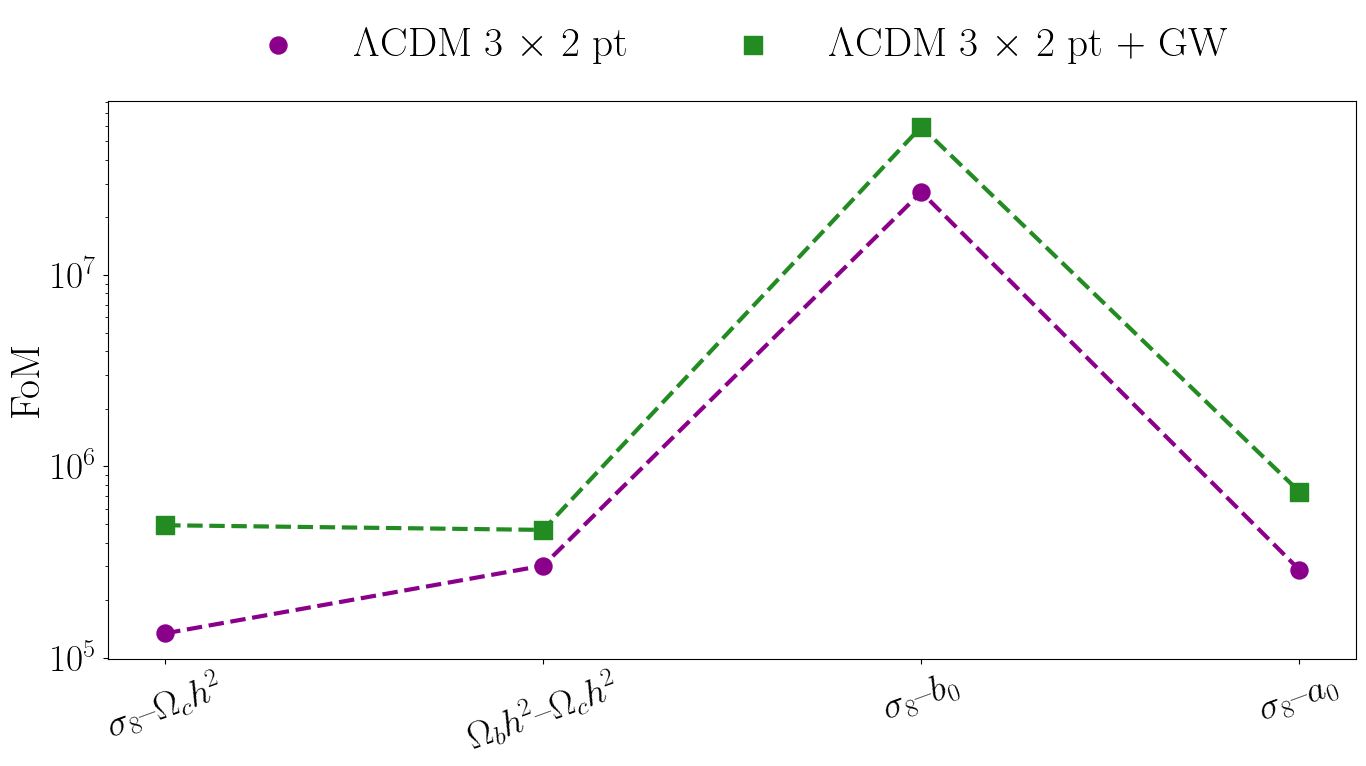

In [141]:
import matplotlib.pyplot as plt
import numpy as np

pairs_labels = [
    r"$\sigma_8$–$\Omega_c h^2$",
    r"$\Omega_b h^2$–$\Omega_c h^2$",
    r"$\sigma_8$–$b_0$",
        
    r"$\sigma_8$–$a_0$",

]
pairs = [
    ("sigma8", "omch2"),
    ("ombh2", "omch2"),
    ("sigma8", "a0"),
    ("sigma8", "b0_poly")
]
FoM_3x2   = np.array([FoM_LCDM_3x2[p] for p in pairs])
FoM_3x2GW = np.array([FoM_LCDM_3x2GW[p] for p in pairs])

x = np.arange(len(pairs))

plt.figure(figsize=(14,8))

# --- Points ---
plt.scatter(x, FoM_3x2,   s=150, marker="o", color="darkmagenta",  label=r'$\Lambda$CDM 3 $\times$ 2 pt ')
plt.scatter(x, FoM_3x2GW, s=150, marker="s", color="forestgreen", label=r'$\Lambda$CDM 3 $\times$ 2 pt + GW ')

# --- Connect circles with circles ---
plt.plot(x, FoM_3x2,   color="darkmagenta",  lw=3, ls ="--")

# --- Connect squares with squares ---
plt.plot(x, FoM_3x2GW, color="forestgreen", lw=3, ls ="--")

plt.xticks(x, pairs_labels, fontsize=27, rotation=20)
plt.yticks(fontsize=27)
plt.ylabel("FoM", fontsize=30)
plt.yscale("log")
plt.legend(
    fontsize=30,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=2,
    frameon=False
)
plt.tight_layout()
plt.show()


In [23]:
# import pandas as pd
# import yaml
# from camb import CAMBparams, get_results


# chain_file = "chains_final_noiseless/muSigmaCDM_3x2pt+GW_final_chain.txt"
# yaml_file = "chains_final_noiseless/muSigmaCDM_3x2pt+GW_final.params.yaml"

# with open(yaml_file, 'r') as f:
#     params_yaml = yaml.safe_load(f)

# chain = pd.read_csv(chain_file, sep='\s+', header=None)

# all_params = list(params_yaml['params'].keys())


In [24]:
from camb import CAMBparams, get_results
import camb
import numpy as np
cosmo_pars = {
    'omch2': 0.1216,
    'ombh2': 0.0229,
    'H0': 67.2,
    'As': np.exp(3.052)*1e-10,
    'ns': 0.9584,
    'tau': 0.05,
    'mu0': 0.005,
    'sigma0': -0.003,
}
pars = camb.set_params(**cosmo_pars)
pars.set_matter_power(redshifts=[0], kmax=2.0)
results = get_results(pars)
sigma8_fid = results.get_sigma8()[0]
print(f"Fiducial sigma8: {sigma8_fid}")

Fiducial sigma8: 0.8149940265899819


In [25]:
# import pandas as pd
# import yaml
# from camb import CAMBparams, get_results
# import numpy as np
# import camb
# chain_file = "chains_final_noiseless/muSigmaCDM_3x2pt+GW_final_chain.txt"
# yaml_file = "chains_final_noiseless/muSigmaCDM_3x2pt+GW_final.params.yaml"

# # --- Load YAML ---
# with open(yaml_file, 'r') as f:
#     params_yaml = yaml.safe_load(f)

# # --- Read chain file ---
# chain = pd.read_csv(chain_file, sep=r"\s+", header=None)

# # Infer correct column names:
# # (usually Nautilus files are "weight minuslogpost" + parameters)
# all_params = list(params_yaml['params'].keys())
# colnames = ['weight', 'minuslogpost'] + all_params
# colnames = colnames[:len(chain.columns)]  # truncate if extra columns

# chain.columns = colnames

# print("Column names assigned:")
# print(chain.columns.tolist())

# # --- Compute sigma8 ---
# def compute_sigma8(row):
#     try:
#         cosmo_pars = {
#             'omch2': row['omch2'],
#             'ombh2': row['ombh2'],
#             'H0': row['H0'],
#             'As': np.exp(row['logA'])*1e-10,
#             'ns': row['ns'],
#             'tau': fiducial['tau'],
#             'mu0': row.get('mu0', 0.0),
#             'sigma0': row.get('sigma0', 0.0),
#         }
#         pars = camb.set_params(**cosmo_pars)
#         pars.set_matter_power(redshifts=[0], kmax=2.0)
#         results = get_results(pars)
#         sigma8 = results.get_sigma8()[0]
#         return sigma8
#     except Exception as e:
#         print(f"Error at row: {e}")
#         return np.nan
# chain['sigma8'] = chain.apply(compute_sigma8, axis=1)
# # --- Save ---
# output_txt = "chains_final_noiseless/muSigmaCDM_3x2pt+GW_final_sigma8_new_chain.txt"
# chain.to_csv(output_txt, sep='\t', index=False)
# print(f"Saved {output_txt}")

# # --- Optional: write mean values ---
# required_params = ['ombh2', 'omch2', 'H0', 'ns', 'logA', 'mu0', 'sigma0']
# yaml_out = {
#     "parameters": {p: float(chain[p].mean()) for p in required_params if p in chain.columns},
#     "sigma8_mean": float(chain['sigma8'].mean())
# }



In [26]:


# output_yaml = "chains_final_noiseless/muSigmaCDM_3x2pt+GW_final_sigma8_new.params.yaml"

# with open(yaml_file, "r") as f:
#     params_yaml = yaml.safe_load(f)

# sigma8_mean = float(chain["sigma8"].mean())

# params_yaml["params"]["sigma8"] = {
#     "latex": "\\sigma_8",
#     "derived": True,
#     "value": float(f"{sigma8_mean:.5f}")
# }

# with open(output_yaml, "w") as f:
#     yaml.dump(params_yaml, f, sort_keys=False)
